<a href="https://colab.research.google.com/github/Aghil-hub/spotify-barcelona-brand-impact/blob/main/spotify_barcelona_reddit_sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction

This notebook performs sentiment analysis on Reddit comments discussing two FC Barcelona × Spotify announcements: the shirt sponsorship deal and the Camp Nou stadium renaming.
* The analysis loads a pre-scraped dataset of Reddit comments, applies a multi-step text preprocessing pipeline, and conducts exploratory data analysis to examine comment volume and distribution across the two events.
* Sentiment is scored using two RoBERTa-based transformer models — a baseline comment-only model and a context-aware model that incorporates parent comment text for reply threads. The two models are compared, a confidence threshold (≥0.60) is applied to filter low-certainty predictions, and the **baseline model is selected for downstream analysis based on manual inspection of disagreement cases.**
* The notebook concludes with author-level sentiment aggregation and visual summaries of the results.

# Section 0: Environment Setup & Imports
Installs required Python packages (pandas, transformers, torch, ftfy, etc.) and imports all libraries needed for data scraping, text preprocessing, visualization, and sentiment modeling.

In [1]:
!pip -q install pandas openpyxl requests
!pip -q install transformers torch scipy sentencepiece accelerate
!pip install ftfy --quiet
!pip install contractions emoji --quiet

In [2]:
import os
import time
from datetime import datetime
import pandas as pd
import requests
import ftfy
import re
import re
import contractions
import emoji
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
import numpy as np
import seaborn as sns
from scipy.special import softmax
from transformers import AutoTokenizer, AutoConfig, AutoModelForSequenceClassification
from tqdm import tqdm
import torch

# Section 1: Data Collection — Reddit Comment Scraping (Optional)

Defines the Reddit post URLs and metadata (11 posts across Reddit threads) for two events: the Spotify sponsorship deal with FC Barcelona and the stadium renaming to "Spotify Camp Nou." Uses the Arctic Shift Reddit archive API to fetch comments, constructs a structured dataset, and exports to CSV/Excel. **This section is commented out since data has already been scraped.**

In [3]:
# POSTS = [
#     ("Deal Announcement", "tez4so", "Barca", "[FC Barcelona] Announcement of Official Partnership with Spotify"),
#     ("Deal Announcement", "tfk3ra", "soccer", "[SPORT] Barcelona's kit sponsor within the Spotify agreements - artist names on kit"),
#     ("Deal Announcement", "telmd8", "Barca", "Spotify's sponsorship deal with Barcelona could have been worth much more!"),
#     ("Deal Announcement", "tfkaua", "soccer", "[Sport] The agreement between Barça and Spotify will turn the shirt into a space for artists"),
#     ("Deal Announcement", "t4yy4p", "Barca", "What happened to the Spotify deal? Why it's not announced yet?"),
#     ("Deal Announcement", "tezjk3", "Barca", "BREAKING: Barcelona have officially partnered with Spotify. Spotify Camp Nou."),
#     ("Deal Announcement", "tez8e7", "soccer", "Spotify and FC Barcelona announce a first-of-its-kind partnership"),
#     ("Renaming Announcement", "tfjdm3", "football", "FC Barcelona's stadium will soon be renamed Spotify Camp Nou"),
#     ("Renaming Announcement", "tejazz", "Barca", "[Fernando Polo] Spotify are now demanding 'naming rights' of the Camp Nou"),
#     ("Renaming Announcement", "tg183r", "soccer", "Spotify to Become FC Barcelona's Main Shirt Sponsor"),
#     ("Renaming Announcement", "tgda11", "soccer", "FC Barcelona's massive stadium is now Spotify Camp Nou"),
# ]

# BASE_URL = "https://arctic-shift.photon-reddit.com/api/comments/search"
# HEADERS = {"User-Agent": "colab-reddit-scraper/1.0"}
# OUTPUT_DIR = "output"
# os.makedirs(OUTPUT_DIR, exist_ok=True)

In [4]:
# def fetch_all_comments(link_id, max_requests=15, sleep_seconds=0.4):
#     all_comments, seen_ids, after_utc = [], set(), None
#     for _ in range(max_requests):
#         params = {"link_id": link_id, "limit": 100}
#         if after_utc:
#             params["after"] = str(int(after_utc))
#         r = requests.get(BASE_URL, params=params, headers=HEADERS, timeout=20)
#         r.raise_for_status()
#         batch = r.json().get("data") or []
#         if not batch:
#             break
#         new_comments = [c for c in batch if c.get("id") not in seen_ids]
#         if not new_comments:
#             break
#         for c in new_comments:
#             seen_ids.add(c.get("id"))
#         all_comments.extend(new_comments)
#         if len(batch) < 100:
#             break
#         last_utc = batch[-1].get("created_utc", 0)
#         if last_utc == after_utc:
#             break
#         after_utc = last_utc
#         time.sleep(sleep_seconds)
#     return all_comments

# def build_dataset(posts):
#     rows = []
#     for Topic, post_id, subreddit, post_title in posts:
#         comments = fetch_all_comments(post_id)
#         for c in comments:
#             body = c.get("body", "")
#             if not body or body in ("[deleted]", "[removed]"):
#                 continue
#             parent_id = c.get("parent_id", "")
#             comment_class = "top-level" if parent_id.startswith("t3_") else "reply"
#             rows.append({
#                 "Topic": Topic,
#                 "post_title": post_title,
#                 "post_url": f"https://reddit.com/r/{subreddit}/comments/{post_id}/",
#                 "subreddit": f"r/{subreddit}",
#                 "comment_id": c.get("id", ""),
#                 "parent_id": parent_id,
#                 "comment": body,
#                 "class": comment_class,
#                 "author": c.get("author", "[deleted]"),
#                 "score": c.get("score", 0),
#                 "created_date": datetime.utcfromtimestamp(float(c.get("created_utc", 0))).strftime("%Y-%m-%d %H:%M:%S")
#             })
#         print(f"{post_id}: {len(comments)} comments fetched")
#         time.sleep(0.8)
#     return pd.DataFrame(rows)


In [5]:
# df = build_dataset(POSTS)
# df.shape

In [6]:
# csv_path = os.path.join(OUTPUT_DIR, 'spotify_barcelona_reddit_comments.csv')
# xlsx_path = os.path.join(OUTPUT_DIR, 'spotify_barcelona_reddit_comments.xlsx')

# df.to_csv(csv_path, index=False)
# df.to_excel(xlsx_path, index=False)

# print('Saved:', csv_path)
# print('Saved:', xlsx_path)



---





# Section 2: Load & Explore Raw Data

Loads the pre-scraped Excel dataset, displays the first rows, and prints a summary including total comment count, number of posts covered, subreddit distribution, topic breakdown (Deal vs. Rename announcements), and top-level vs. reply comment split.

**Dataset columns:**
- `Topic` — Event label: *Deal Announcement* (Spotify shirt sponsorship) or *Renaming Announcement* (Camp Nou renamed to Spotify Camp Nou)
- `Class` — Comment type: *top-level* (direct comment on post) or *reply* (response to another comment)
- `Comment` — Raw comment text as scraped
- `Author` — Reddit username
- `Score` — Reddit upvote score
- `Subreddit` — Source community (r/Barca, r/soccer, r/football)
- `Post Title` — Title of the parent Reddit thread
- `Created Date (UTC)` — Timestamp of the comment

In [7]:
OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [8]:
df_excel = pd.read_excel('/content/Spotify_Barcelona_Reddit_Sentiment_Dataset.xlsx')
display(df_excel.head())

,Topic,Post Title,Subreddit,Comment ID,Parent ID,Comment,Class,Author,Score,Created Date (UTC),Post URL
0,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0yvjet,t1_i0tfrwt,Memphis Auba and Alves at the halftime show it...,reply,Dried_Potato39,1,2022-03-17 02:21:20,https://reddit.com/r/Barca/comments/tez4so/
1,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ynejj,t1_i0valr1,I have seen some numbers from espn. Not sure i...,reply,amrla,1,2022-03-17 01:20:04,https://reddit.com/r/Barca/comments/tez4so/
2,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0y5kmm,t1_i0ws44r,Still that doesn't make Rakuten half as bad as...,reply,WolfInATrance,0,2022-03-16 23:07:40,https://reddit.com/r/Barca/comments/tez4so/
3,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ws44r,t1_i0wrlla,You are saying that Rakuten is better than Spo...,reply,FANTASY210,0,2022-03-16 17:40:40,https://reddit.com/r/Barca/comments/tez4so/
4,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0wrlla,t1_i0w9wfi,Yeah so? I'm comparing Rakuten to the Arab com...,reply,WolfInATrance,0,2022-03-16 17:37:16,https://reddit.com/r/Barca/comments/tez4so/


In [9]:
display(df_excel.head())

print("Total comments:", len(df_excel))
print("Posts covered:", df_excel['Post URL'].nunique())
print("Subreddits:")
print(df_excel['Subreddit'].value_counts())
print("\nTopics:")
print(df_excel['Topic'].value_counts())
print("\nClass split:")
print(df_excel['Class'].value_counts())


,Topic,Post Title,Subreddit,Comment ID,Parent ID,Comment,Class,Author,Score,Created Date (UTC),Post URL
0,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0yvjet,t1_i0tfrwt,Memphis Auba and Alves at the halftime show it...,reply,Dried_Potato39,1,2022-03-17 02:21:20,https://reddit.com/r/Barca/comments/tez4so/
1,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ynejj,t1_i0valr1,I have seen some numbers from espn. Not sure i...,reply,amrla,1,2022-03-17 01:20:04,https://reddit.com/r/Barca/comments/tez4so/
2,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0y5kmm,t1_i0ws44r,Still that doesn't make Rakuten half as bad as...,reply,WolfInATrance,0,2022-03-16 23:07:40,https://reddit.com/r/Barca/comments/tez4so/
3,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ws44r,t1_i0wrlla,You are saying that Rakuten is better than Spo...,reply,FANTASY210,0,2022-03-16 17:40:40,https://reddit.com/r/Barca/comments/tez4so/
4,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0wrlla,t1_i0w9wfi,Yeah so? I'm comparing Rakuten to the Arab com...,reply,WolfInATrance,0,2022-03-16 17:37:16,https://reddit.com/r/Barca/comments/tez4so/


Total comments: 328
Posts covered: 11
Subreddits:
Subreddit
r/Barca       129
r/soccer      124
r/football     75
Name: count, dtype: int64

Topics:
Topic
Deal Announcement        217
Renaming Announcement    111
Name: count, dtype: int64

Class split:
Class
reply        198
top-level    130
Name: count, dtype: int64


In [10]:
# Check column names first
print(df_excel.columns.tolist())

['Topic', 'Post Title', 'Subreddit', 'Comment ID', 'Parent ID', 'Comment', 'Class', 'Author', 'Score', 'Created Date (UTC)', 'Post URL']


# Section 3: Data Cleaning

Removes 31 rows from 328 total, reducing to 297 clean comments. Filters applied include:

* Bot/spam author removal (AutoModerator, BotDefense, etc.)

* Deleted/removed account removal

* Short comment filtering (<10 characters)

* Deleted/removed comment body removal

In [11]:
# =============================================================
# STEP: Remove Bots & Spam
# Filters: AutoModerator, BotDefense, other known bots,
#          deleted/removed authors, and comments < 10 characters
# =============================================================

# --- Define bot/spam author list (case-insensitive) ---
BOT_AUTHORS = [
    'automoderator',
    'botdefense',
    'anti-evil operations',
    'reddit',
    'redditcareresources',
    'sneakpeekbot',
    'coveragebot',
    'bot-killer',
    'repostsleuthbot',
]

# --- Record counts before filtering ---
before = len(df_excel)
print(f"Rows before filtering: {before}")

# --- Flag 1: Bot/known-spam authors (case-insensitive match) ---
bot_mask = df_excel['Author'].str.lower().isin(BOT_AUTHORS)

# --- Flag 2: Deleted or removed accounts ---
deleted_mask = df_excel['Author'].str.strip().isin(['[deleted]', '[removed]', 'nan']) | df_excel['Author'].isna()

# --- Flag 3: Comment text too short (< 10 characters) ---
short_mask = df_excel['Comment'].fillna('').str.strip().str.len() < 10

# --- Flag 4: Deleted/removed comment body ---
body_removed_mask = df_excel['Comment'].str.strip().isin(['[deleted]', '[removed]'])

# --- Combine all exclusion flags ---
exclude_mask = bot_mask | deleted_mask | short_mask | body_removed_mask

# --- Apply filter ---
df_clean = df_excel[~exclude_mask].copy().reset_index(drop=True)

# --- Report breakdown ---
after = len(df_clean)
print(f"Rows after filtering:  {after}")
print(f"Total rows removed:    {before - after}")
print()
print("Breakdown of removed rows:")
print(f"  Bot/spam authors   : {bot_mask.sum()}")
print(f"  Deleted accounts   : {deleted_mask.sum()}")
print(f"  Short comments (<10): {short_mask.sum()}")
print(f"  Removed body text  : {body_removed_mask.sum()}")
print(f"  (Note: some rows may overlap multiple flags)")

print()
print("Preview of cleaned DataFrame:")
display(df_clean.head())

Rows before filtering: 328
Rows after filtering:  297
Total rows removed:    31

Breakdown of removed rows:
  Bot/spam authors   : 1
  Deleted accounts   : 8
  Short comments (<10): 22
  Removed body text  : 0
  (Note: some rows may overlap multiple flags)

Preview of cleaned DataFrame:


,Topic,Post Title,Subreddit,Comment ID,Parent ID,Comment,Class,Author,Score,Created Date (UTC),Post URL
0,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0yvjet,t1_i0tfrwt,Memphis Auba and Alves at the halftime show it...,reply,Dried_Potato39,1,2022-03-17 02:21:20,https://reddit.com/r/Barca/comments/tez4so/
1,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ynejj,t1_i0valr1,I have seen some numbers from espn. Not sure i...,reply,amrla,1,2022-03-17 01:20:04,https://reddit.com/r/Barca/comments/tez4so/
2,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0y5kmm,t1_i0ws44r,Still that doesn't make Rakuten half as bad as...,reply,WolfInATrance,0,2022-03-16 23:07:40,https://reddit.com/r/Barca/comments/tez4so/
3,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ws44r,t1_i0wrlla,You are saying that Rakuten is better than Spo...,reply,FANTASY210,0,2022-03-16 17:40:40,https://reddit.com/r/Barca/comments/tez4so/
4,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0wrlla,t1_i0w9wfi,Yeah so? I'm comparing Rakuten to the Arab com...,reply,WolfInATrance,0,2022-03-16 17:37:16,https://reddit.com/r/Barca/comments/tez4so/


## Step 3.1: Fix Encoding Issues (Mojibake)

Uses ftfy to repair garbled text encoding (e.g., "BarÃ§a" → "Barça") across Comment and Post Title columns. Verifies the fix by scanning for remaining mojibake patterns and prints sample comments to confirm.

In [12]:
# =============================================================
# STEP: Fix Encoding (Mojibake) using ftfy
# Converts garbled text like 'BarÃ§a' -> 'Barça'
# Applied to all text columns in df_clean
# =============================================================

# --- Text columns to fix ---
TEXT_COLS = ['Comment', 'Post Title']

# --- Apply ftfy.fix_text to each text column ---
for col in TEXT_COLS:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(str).apply(ftfy.fix_text)

print("Encoding fix applied to columns:", TEXT_COLS)
print()

# --- Verification: show sample before/after by scanning for common mojibake patterns ---

MOJIBAKE_PATTERN = re.compile(r'[\xc0-\xff]{2,}|Ã|Â|â€')

# Check remaining mojibake in Comment column
still_broken = df_clean['Comment'].apply(lambda x: bool(MOJIBAKE_PATTERN.search(x)))
print(f"Comments still containing potential mojibake after fix: {still_broken.sum()}")

# --- Show a sample of fixed comments to verify ---
print()
print("Sample of 5 comments after encoding fix:")
for i, row in df_clean[['Author', 'Comment']].head(5).iterrows():
    print(f"  [{i}] {row['Author']}: {row['Comment'][:120]}")

Encoding fix applied to columns: ['Comment', 'Post Title']

Comments still containing potential mojibake after fix: 0

Sample of 5 comments after encoding fix:
  [0] Dried_Potato39: Memphis Auba and Alves at the halftime show it's gonna be crazy lol
  [1] amrla: I have seen some numbers from espn. Not sure if that is the right one though
  [2] WolfInATrance: Still that doesn't make Rakuten half as bad as the arab companies. First thing, second Spotify is shrewd in business. An
  [3] FANTASY210: You are saying that Rakuten is better than Spotify because Spotify just like these other companies want title rights, th
  [4] WolfInATrance: Yeah so? I'm comparing Rakuten to the Arab companies and saying it was way better. you legit are blind. Never mentioned 


## Step 3.2: Text Preprocessing Pipeline

A multi-step pipeline to prepare comment text for sentiment analysis:

**Step 1:** Remove URLs, Markdown artifacts (bold, italic, strikethrough, code, headers, links), and Reddit boilerplate phrases

**Step 2:** Expand contractions while preserving negation (e.g., "can't" → "cannot")

**Step 3:** Convert Unicode emojis and text-based emoticons into descriptive token labels (e.g., ":-)" → "EMO_HAPPY")

**Step 4:** Flag and handle quoted text; mark quote-heavy comments

**Step 5:** Add aspect/entity columns for targeted analysis

In [13]:
# =============================================================
# STEPS: Text Preprocessing Pipeline
# 1. Remove URLs, Markdown artifacts, boilerplate
# 2. Expand contractions + preserve negation
# 3. Convert emojis/emoticons to text tokens
# 4. Flag quoted text + mark quote-heavy comments
# 5. Add aspect/entity columns
# =============================================================


# ── Emoticon map (text-based faces -> word tokens) ──────────────────────────
EMOTICON_MAP = {
    r':-?\)': ' EMO_HAPPY ',   r':-?D': ' EMO_BIGGRIN ',
    r':-?\(': ' EMO_SAD ',     r';-?\)': ' EMO_WINK ',
    r':-?P': ' EMO_TONGUE ',   r':-?/': ' EMO_UNSURE ',
    r':-?\|': ' EMO_NEUTRAL ', r'>:-?\(': ' EMO_ANGRY ',
    r':-?O': ' EMO_SURPRISED ',r":'\(": ' EMO_CRYING ',
    r'\^_?\^': ' EMO_HAPPY ',  r'<3': ' EMO_LOVE ',
    r'xD': ' EMO_BIGGRIN ',    r'D:': ' EMO_SHOCKED ',
    r':\)': ' EMO_HAPPY ',     r':\(': ' EMO_SAD ',
}

# ── Negation preservation helper ────────────────────────────────────────────
NEGATION_PAIRS = [
    (r"can't", "cannot"),   (r"won't", "will not"),
    (r"n't", " not"),       (r"'re", " are"),
    (r"'ve", " have"),      (r"'ll", " will"),
    (r"'d", " would"),      (r"'m", " am"),
]

# ── Reddit boilerplate phrases to strip ─────────────────────────────────────
BOILERPLATE_PATTERNS = [
    r'I am a bot.*?(\.|$)',
    r'This action was performed automatically.*?(\.|$)',
    r'Please contact the moderators.*?(\.|$)',
    r'\*I am a bot\*.*?(\.|$)',
    r'\^\(I am a bot\).*?(\.|$)',
]

# ────────────────────────────────────────────────────────────────────────────
# STEP 1 — Clean: URLs, Markdown, boilerplate
# ────────────────────────────────────────────────────────────────────────────
def clean_text(text):
    text = str(text)
    # Strip URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # Strip Reddit markdown: **bold**, *italic*, ~~strikethrough~~, `code`, #headers
    text = re.sub(r'\*{1,3}(.*?)\*{1,3}', r'\1', text)   # bold/italic
    text = re.sub(r'~~(.*?)~~', r'\1', text)               # strikethrough
    text = re.sub(r'`[^`]*`', '', text)                    # inline code
    text = re.sub(r'^#{1,6}\s+', '', text, flags=re.MULTILINE)  # headers
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)  # [text](url) -> text
    text = re.sub(r'\[([^\]]+)\]', r'\1', text)           # bare [text]
    text = re.sub(r'^>+\s?', '', text, flags=re.MULTILINE) # leading > (blockquote marker cleanup)
    text = re.sub(r'[-_]{3,}', ' ', text)                  # hr / separators
    # Strip boilerplate
    for pat in BOILERPLATE_PATTERNS:
        text = re.sub(pat, '', text, flags=re.IGNORECASE | re.DOTALL)
    # Collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['comment_clean'] = df_clean['Comment'].apply(clean_text)
print("STEP 1 done — URLs, Markdown, boilerplate removed.")

# ────────────────────────────────────────────────────────────────────────────
# STEP 2 — Expand contractions + preserve negation
# ────────────────────────────────────────────────────────────────────────────
def expand_and_preserve(text):
    # Negation-critical pairs first (before contractions library rewrites them)
    for pat, repl in NEGATION_PAIRS:
        text = re.sub(pat, repl, text, flags=re.IGNORECASE)
    # Then general contractions
    text = contractions.fix(text)
    return text

df_clean['comment_clean'] = df_clean['comment_clean'].apply(expand_and_preserve)
print("STEP 2 done — contractions expanded, negation preserved.")

# ────────────────────────────────────────────────────────────────────────────
# STEP 3 — Convert emojis + emoticons to text tokens
# ────────────────────────────────────────────────────────────────────────────
def emoji_to_text(text):
    # Convert Unicode emojis to descriptive text, e.g. 😂 -> :face_with_tears_of_joy:
    text = emoji.demojize(text, delimiters=(' EMO_', ' '))
    # Convert text emoticons
    for pat, token in EMOTICON_MAP.items():
        text = re.sub(pat, token, text, flags=re.IGNORECASE)
    # Clean up any double spaces introduced
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df_clean['comment_clean'] = df_clean['comment_clean'].apply(emoji_to_text)
print("STEP 3 done — emojis and emoticons converted to text tokens.")

# ────────────────────────────────────────────────────────────────────────────
# STEP 4 — Flag quoted text + quote-heavy comments
# ────────────────────────────────────────────────────────────────────────────
def extract_quote_ratio(text):
    """Returns fraction of lines that are Reddit blockquotes (start with >)."""
    lines = str(text).splitlines()
    if not lines:
        return 0.0
    quote_lines = [l for l in lines if l.strip().startswith('>')]
    return len(quote_lines) / len(lines)

# is_quote_heavy = True if >50% of lines are quotes OR comment starts with >
df_clean['quote_ratio']    = df_clean['Comment'].apply(extract_quote_ratio)
df_clean['is_quote_heavy'] = df_clean['quote_ratio'] > 0.5

print(f"STEP 4 done — {df_clean['is_quote_heavy'].sum()} comments flagged as quote-heavy (>50% quoted lines).")

# ────────────────────────────────────────────────────────────────────────────
# STEP 5 — Aspect / entity columns
# ────────────────────────────────────────────────────────────────────────────

# Keywords for each aspect (case-insensitive)
ASPECT_KEYWORDS = {
    'mentions_spotify': [
        r'\bspotify\b', r'\bstreaming\b', r'\bspotify deal\b',
        r'\bspotify sponsor\b', r'\bspotify partner\b',
    ],
    'mentions_barca': [
        r'\bbar[cç]a\b', r'\bfcb\b', r'\bfc barcelona\b',
        r'\bblaugrana\b', r'\bcul[eé]s?\b', r'\bbarcelona\b',
    ],
    'mentions_camp_nou_rename': [
        r'\bcamp nou\b', r'\bespotify camp nou\b', r'\bstadium rename\b',
        r'\bnaming rights\b', r'\bstadium name\b', r'\brename\b',
        r'\bnew name\b', r'\bstadium sponsor\b',
    ],
    'mentions_artists': [
        r'\bthe weeknd\b', r'\bshakira\b', r'\bbad bunny\b',
        r'\brauw alejandro\b', r'\brosalia\b', r'\bartist\b',
        r'\bmusician\b', r'\bconcert\b', r'\bperformer\b',
        r'\bplaylist\b', r'\balbum\b', r'\btrack\b',
    ],
}

for col, patterns in ASPECT_KEYWORDS.items():
    combined = '|'.join(patterns)
    df_clean[col] = df_clean['comment_clean'].str.contains(
        combined, flags=re.IGNORECASE, regex=True, na=False
    ).astype(int)

print("STEP 5 done — aspect/entity columns added.")
print()
print("Aspect coverage summary:")
for col in ASPECT_KEYWORDS:
    n = df_clean[col].sum()
    pct = 100 * n / len(df_clean)
    print(f"  {col:<30}: {n:>4} comments ({pct:.1f}%)")

print()
print("Final df_clean columns:")
print(df_clean.columns.tolist())
print()
print("Sample — comment_clean preview (first 3 rows):")
for i, row in df_clean[['comment_clean','is_quote_heavy','mentions_spotify','mentions_barca','mentions_camp_nou_rename','mentions_artists']].head(3).iterrows():
    print(f"[{i}] {row['comment_clean'][:100]}")
    print(f"     quote_heavy={row['is_quote_heavy']} | spotify={row['mentions_spotify']} | barca={row['mentions_barca']} | camp_nou={row['mentions_camp_nou_rename']} | artists={row['mentions_artists']}")

STEP 1 done — URLs, Markdown, boilerplate removed.
STEP 2 done — contractions expanded, negation preserved.
STEP 3 done — emojis and emoticons converted to text tokens.
STEP 4 done — 1 comments flagged as quote-heavy (>50% quoted lines).
STEP 5 done — aspect/entity columns added.

Aspect coverage summary:
  mentions_spotify              :   44 comments (14.8%)
  mentions_barca                :   32 comments (10.8%)
  mentions_camp_nou_rename      :   24 comments (8.1%)
  mentions_artists              :   16 comments (5.4%)

Final df_clean columns:
['Topic', 'Post Title', 'Subreddit', 'Comment ID', 'Parent ID', 'Comment', 'Class', 'Author', 'Score', 'Created Date (UTC)', 'Post URL', 'comment_clean', 'quote_ratio', 'is_quote_heavy', 'mentions_spotify', 'mentions_barca', 'mentions_camp_nou_rename', 'mentions_artists']

Sample — comment_clean preview (first 3 rows):
[0] Memphis Auba and Alves at the halftime show it is going to be crazy lol
     quote_heavy=False | spotify=0 | barca=0 | ca

In [14]:
df_clean.head()

,Topic,Post Title,Subreddit,Comment ID,Parent ID,Comment,Class,Author,Score,Created Date (UTC),Post URL,comment_clean,quote_ratio,is_quote_heavy,mentions_spotify,mentions_barca,mentions_camp_nou_rename,mentions_artists
0,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0yvjet,t1_i0tfrwt,Memphis Auba and Alves at the halftime show it...,reply,Dried_Potato39,1,2022-03-17 02:21:20,https://reddit.com/r/Barca/comments/tez4so/,Memphis Auba and Alves at the halftime show it...,0.0,False,0,0,0,0
1,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ynejj,t1_i0valr1,I have seen some numbers from espn. Not sure i...,reply,amrla,1,2022-03-17 01:20:04,https://reddit.com/r/Barca/comments/tez4so/,I have seen some numbers from espn. Not sure i...,0.0,False,0,0,0,0
2,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0y5kmm,t1_i0ws44r,Still that doesn't make Rakuten half as bad as...,reply,WolfInATrance,0,2022-03-16 23:07:40,https://reddit.com/r/Barca/comments/tez4so/,Still that does not make Rakuten half as bad a...,0.0,False,1,1,0,0
3,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0ws44r,t1_i0wrlla,You are saying that Rakuten is better than Spo...,reply,FANTASY210,0,2022-03-16 17:40:40,https://reddit.com/r/Barca/comments/tez4so/,You are saying that Rakuten is better than Spo...,0.0,False,1,0,0,0
4,Deal Announcement,[FC Barcelona] Announcement of Official Partne...,r/Barca,i0wrlla,t1_i0w9wfi,Yeah so? I'm comparing Rakuten to the Arab com...,reply,WolfInATrance,0,2022-03-16 17:37:16,https://reddit.com/r/Barca/comments/tez4so/,Yeah so? I am comparing Rakuten to the Arab co...,0.0,False,1,0,0,0


# Section 4: Exploratory Data Analysis (EDA)

Examines the temporal patterns and composition of the Reddit comments dataset.

Deal Announcement   : 203 comments across 5 days
Renaming Announcement: 94 comments across 3 days

Deal date range   : 2022-03-02 to 2022-03-17
Rename date range : 2022-03-15 to 2022-03-17


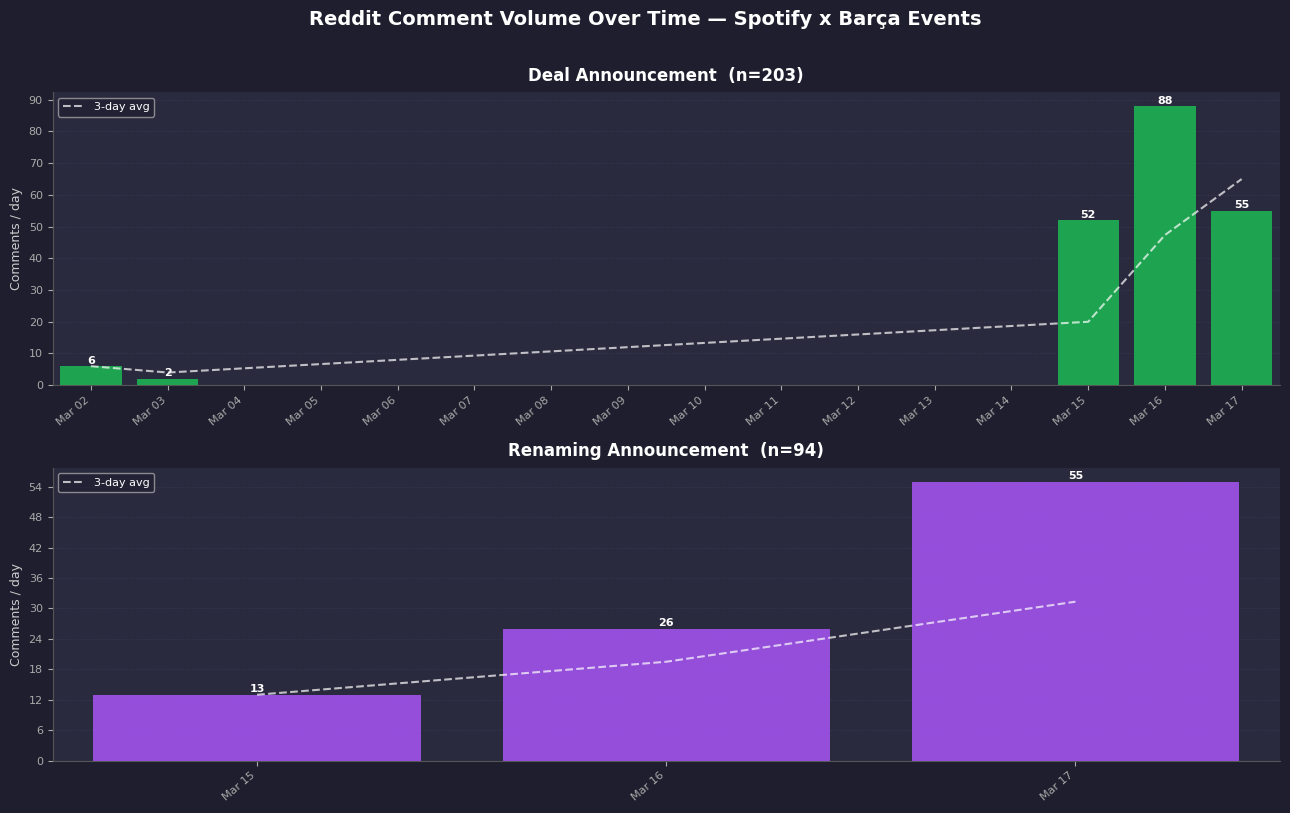

Saved: /content/output/date_distribution.png


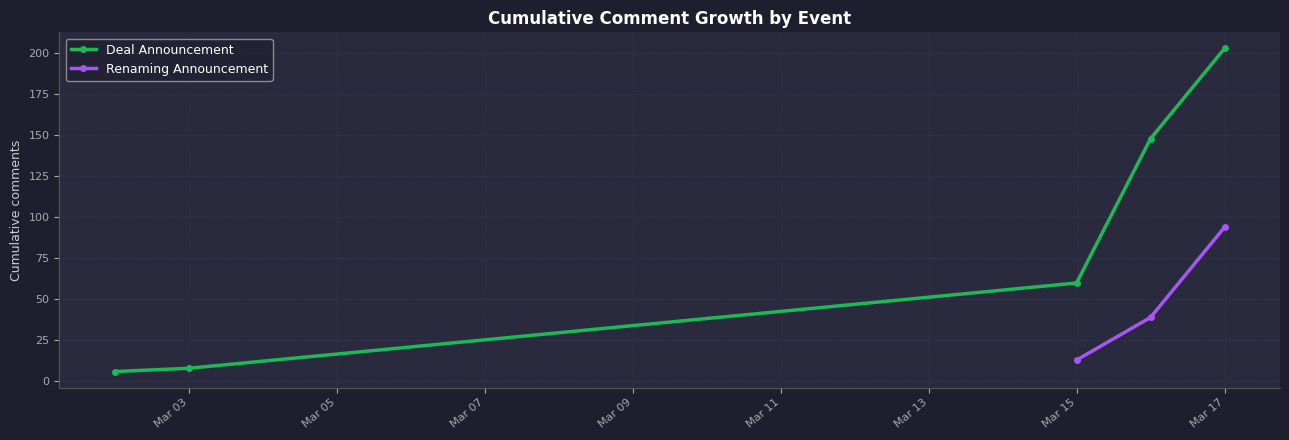

Saved: /content/output/cumulative_growth.png


In [15]:
# =============================================================
# Comment Date Distribution — by Event (Deal vs Rename)
# =============================================================


# --- Parse date column ---
df_clean['date'] = pd.to_datetime(df_clean['Created Date (UTC)'], errors='coerce')
df_clean['date_day'] = df_clean['date'].dt.normalize()  # floor to day

# --- Split by event ---
df_deal   = df_clean[df_clean['Topic'] == 'Deal Announcement'].copy()
df_rename = df_clean[df_clean['Topic'] == 'Renaming Announcement'].copy()

# Daily comment counts per event
deal_daily   = df_deal.groupby('date_day').size().reset_index(name='count')
rename_daily = df_rename.groupby('date_day').size().reset_index(name='count')

print(f"Deal Announcement   : {len(df_deal)} comments across {deal_daily['date_day'].nunique()} days")
print(f"Renaming Announcement: {len(df_rename)} comments across {rename_daily['date_day'].nunique()} days")
print()
print("Deal date range   :", df_deal['date'].min().date(), "to", df_deal['date'].max().date())
print("Rename date range :", df_rename['date'].min().date(), "to", df_rename['date'].max().date())

# =============================================================
# FIGURE 1: Side-by-side daily bar charts
# =============================================================
fig, axes = plt.subplots(2, 1, figsize=(13, 8), facecolor='#1e1e2e')

EVENTS = [
    (df_deal,   deal_daily,   'Deal Announcement',    '#1DB954', axes[0]),   # Spotify green
    (df_rename, rename_daily, 'Renaming Announcement', '#a855f7', axes[1]),  # purple
]

for df_ev, daily, title, color, ax in EVENTS:
    ax.set_facecolor('#2a2a3e')
    bars = ax.bar(daily['date_day'], daily['count'],
                  color=color, alpha=0.85, width=0.8, zorder=3)
    # Value labels on bars
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.15, str(int(h)),
                    ha='center', va='bottom', fontsize=8, color='white', fontweight='bold')
    # Rolling 3-day average line
    if len(daily) >= 3:
        daily_sorted = daily.sort_values('date_day')
        roll = daily_sorted['count'].rolling(3, min_periods=1).mean()
        ax.plot(daily_sorted['date_day'], roll, color='white',
                linewidth=1.5, linestyle='--', alpha=0.7, label='3-day avg', zorder=4)
        ax.legend(fontsize=8, facecolor='#1e1e2e', labelcolor='white', framealpha=0.6)
    # Styling
    ax.set_title(f'{title}  (n={len(df_ev)})', color='white', fontsize=12, fontweight='bold', pad=8)
    ax.set_ylabel('Comments / day', color='#cccccc', fontsize=9)
    ax.tick_params(colors='#aaaaaa', labelsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=max(1, len(daily)//10)))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=40, ha='right')
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    ax.spines[['top','right']].set_visible(False)
    ax.spines[['left','bottom']].set_color('#555555')
    ax.grid(axis='y', color='#444466', linestyle=':', alpha=0.5, zorder=0)
    ax.set_xlim(
        daily['date_day'].min() - pd.Timedelta(days=0.5),
        daily['date_day'].max() + pd.Timedelta(days=0.5)
    )

fig.suptitle('Reddit Comment Volume Over Time — Spotify x Barça Events',
             color='white', fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('/content/output/date_distribution.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved: /content/output/date_distribution.png')

# =============================================================
# FIGURE 2: Cumulative comment growth
# =============================================================
fig2, ax2 = plt.subplots(figsize=(13, 4.5), facecolor='#1e1e2e')
ax2.set_facecolor('#2a2a3e')

for daily, label, color in [
    (deal_daily,   'Deal Announcement',    '#1DB954'),
    (rename_daily, 'Renaming Announcement', '#a855f7'),
]:
    ds = daily.sort_values('date_day').copy()
    ds['cumulative'] = ds['count'].cumsum()
    ax2.plot(ds['date_day'], ds['cumulative'], color=color,
             linewidth=2.5, marker='o', markersize=4, label=label)

ax2.set_title('Cumulative Comment Growth by Event',
              color='white', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cumulative comments', color='#cccccc', fontsize=9)
ax2.tick_params(colors='#aaaaaa', labelsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
ax2.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=40, ha='right')
ax2.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
ax2.legend(fontsize=9, facecolor='#1e1e2e', labelcolor='white', framealpha=0.6)
ax2.spines[['top','right']].set_visible(False)
ax2.spines[['left','bottom']].set_color('#555555')
ax2.grid(color='#444466', linestyle=':', alpha=0.5)
fig2.tight_layout()
plt.savefig('/content/output/cumulative_growth.png', dpi=150, bbox_inches='tight',
            facecolor=fig2.get_facecolor())
plt.show()
print('Saved: /content/output/cumulative_growth.png')

DATE FILTER APPLIED: March 15-20, 2022
Before filter: 297 comments
After filter:  289 comments
Removed:       8 comments


1. OVERALL SUMMARY
Total comments:        289
Unique authors:        226
Unique posts:          10
Subreddits:            3 (r/Barca, r/soccer, r/football)
Date range:            2022-03-15 to 2022-03-17
Quote-heavy comments:  1 (0.3%)

Comment length stats (characters):
count    289.000000
mean      90.186851
std       83.206276
min       10.000000
25%       41.000000
50%       63.000000
75%      106.000000
max      556.000000
Name: comment_length, dtype: float64

2. EVENT BREAKDOWN
                       Comments  Unique Authors  Avg Score  Median Score  \
Topic                                                                      
Deal Announcement           195             153       7.12           2.0   
Renaming Announcement        94              79      12.13           5.0   

                       Total Score  Avg Comment Length  
Topic                     

/tmp/ipykernel_61326/82057106.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_filtered, x='Topic', y='Score', ax=ax5,
/tmp/ipykernel_61326/82057106.py:183: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax5.set_xticklabels(ax5.get_xticklabels(), rotation=20, ha='right')


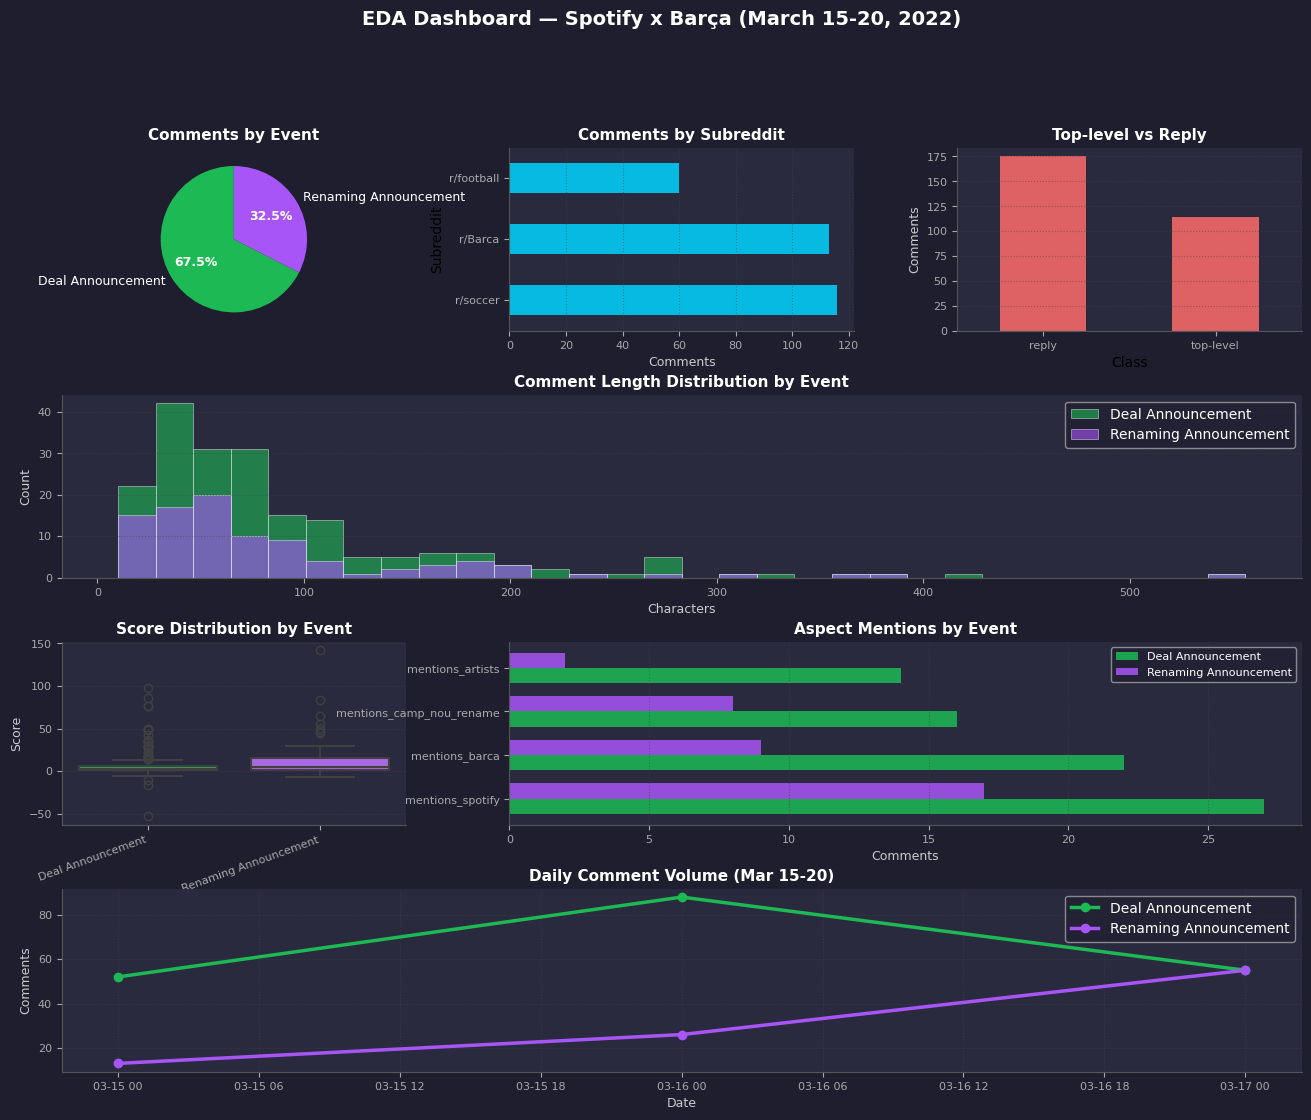


Saved: /content/output/eda_dashboard.png


In [16]:
# =============================================================
# Date Filter: March 15-20, 2022 + EDA Dashboard
# =============================================================

# --- Apply date filter ---
start_date = pd.Timestamp('2022-03-15')
end_date   = pd.Timestamp('2022-03-20 23:59:59')

df_filtered = df_clean[(df_clean['date'] >= start_date) & (df_clean['date'] <= end_date)].copy()

print("="*70)
print("DATE FILTER APPLIED: March 15-20, 2022")
print("="*70)
print(f"Before filter: {len(df_clean)} comments")
print(f"After filter:  {len(df_filtered)} comments")
print(f"Removed:       {len(df_clean) - len(df_filtered)} comments")
print()

# =============================================================
# 1. OVERALL SUMMARY STATS
# =============================================================
print("\n" + "="*70)
print("1. OVERALL SUMMARY")
print("="*70)
print(f"Total comments:        {len(df_filtered)}")
print(f"Unique authors:        {df_filtered['Author'].nunique()}")
print(f"Unique posts:          {df_filtered['Post Title'].nunique()}")
print(f"Subreddits:            {df_filtered['Subreddit'].nunique()} ({', '.join(df_filtered['Subreddit'].unique())})")
print(f"Date range:            {df_filtered['date'].min().date()} to {df_filtered['date'].max().date()}")
print(f"Quote-heavy comments:  {df_filtered['is_quote_heavy'].sum()} ({100*df_filtered['is_quote_heavy'].mean():.1f}%)")
print()
print("Comment length stats (characters):")
df_filtered['comment_length'] = df_filtered['comment_clean'].str.len()
print(df_filtered['comment_length'].describe())

# =============================================================
# 2. EVENT BREAKDOWN
# =============================================================
print("\n" + "="*70)
print("2. EVENT BREAKDOWN")
print("="*70)
event_summary = df_filtered.groupby('Topic').agg({
    'Comment': 'count',
    'Author': 'nunique',
    'Score': ['mean', 'median', 'sum'],
    'comment_length': 'mean'
}).round(2)
event_summary.columns = ['Comments', 'Unique Authors', 'Avg Score', 'Median Score', 'Total Score', 'Avg Comment Length']
print(event_summary)
print()

# =============================================================
# 3. SUBREDDIT BREAKDOWN
# =============================================================
print("\n" + "="*70)
print("3. SUBREDDIT BREAKDOWN")
print("="*70)
subreddit_summary = df_filtered.groupby('Subreddit').agg({
    'Comment': 'count',
    'Author': 'nunique',
    'Score': 'mean',
}).round(2)
subreddit_summary.columns = ['Comments', 'Unique Authors', 'Avg Score']
subreddit_summary = subreddit_summary.sort_values('Comments', ascending=False)
print(subreddit_summary)
print()

# =============================================================
# 4. ASPECT/ENTITY COVERAGE
# =============================================================
print("\n" + "="*70)
print("4. ASPECT/ENTITY MENTION COVERAGE")
print("="*70)
aspect_cols = ['mentions_spotify', 'mentions_barca', 'mentions_camp_nou_rename', 'mentions_artists']
for col in aspect_cols:
    n = df_filtered[col].sum()
    pct = 100 * n / len(df_filtered)
    print(f"{col:<30}: {n:>4} comments ({pct:>5.1f}%)")
print()

# Cross-tabulation: event x aspect
print("Aspect mentions by event:")
for col in aspect_cols:
    ct = pd.crosstab(df_filtered['Topic'], df_filtered[col], margins=True)
    print(f"\n{col}:")
    print(ct)

# =============================================================
# 5. TOP AUTHORS (by comment count)
# =============================================================
print("\n" + "="*70)
print("5. TOP 10 MOST ACTIVE AUTHORS")
print("="*70)
top_authors = df_filtered.groupby('Author').agg({
    'Comment': 'count',
    'Score': 'mean',
}).sort_values('Comment', ascending=False).head(10).round(2)
top_authors.columns = ['Comments', 'Avg Score']
print(top_authors)
print()

# =============================================================
# 6. CLASS DISTRIBUTION (Top-level vs Reply)
# =============================================================
print("\n" + "="*70)
print("6. COMMENT CLASS DISTRIBUTION")
print("="*70)
class_counts = df_filtered['Class'].value_counts()
print(class_counts)
print(f"\nTop-level ratio: {100 * class_counts.get('Top level', 0) / len(df_filtered):.1f}%")
print()

# =============================================================
# CHARTS — Publication-ready EDA dashboard
# =============================================================

fig = plt.figure(figsize=(16, 12), facecolor='#1e1e2e')
gs = fig.add_gridspec(4, 3, hspace=0.35, wspace=0.3)

COLORS = {'Deal Announcement': '#1DB954', 'Renaming Announcement': '#a855f7'}

# --- Chart 1: Event distribution (pie) ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#2a2a3e')
event_counts = df_filtered['Topic'].value_counts()
wedges, texts, autotexts = ax1.pie(event_counts, labels=event_counts.index,
                                     autopct='%1.1f%%', startangle=90,
                                     colors=[COLORS[e] for e in event_counts.index],
                                     textprops={'color': 'white', 'fontsize': 9})
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
ax1.set_title('Comments by Event', color='white', fontsize=11, fontweight='bold')

# --- Chart 2: Subreddit distribution (bar) ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#2a2a3e')
subreddit_counts = df_filtered['Subreddit'].value_counts()
subreddit_counts.plot(kind='barh', ax=ax2, color='#00d4ff', alpha=0.85)
ax2.set_title('Comments by Subreddit', color='white', fontsize=11, fontweight='bold')
ax2.set_xlabel('Comments', color='#ccc', fontsize=9)
ax2.tick_params(colors='#aaa', labelsize=8)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#555')
ax2.grid(axis='x', color='#444', linestyle=':', alpha=0.5)

# --- Chart 3: Comment class (bar) ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#2a2a3e')
class_counts.plot(kind='bar', ax=ax3, color='#ff6b6b', alpha=0.85)
ax3.set_title('Top-level vs Reply', color='white', fontsize=11, fontweight='bold')
ax3.set_ylabel('Comments', color='#ccc', fontsize=9)
ax3.tick_params(colors='#aaa', labelsize=8)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=0)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color('#555')
ax3.grid(axis='y', color='#444', linestyle=':', alpha=0.5)

# --- Chart 4: Comment length distribution (histogram + KDE) ---
ax4 = fig.add_subplot(gs[1, :])
ax4.set_facecolor('#2a2a3e')
for event, color in COLORS.items():
    subset = df_filtered[df_filtered['Topic'] == event]['comment_length']
    ax4.hist(subset, bins=30, alpha=0.6, label=event, color=color, edgecolor='white', linewidth=0.5)
ax4.set_title('Comment Length Distribution by Event', color='white', fontsize=11, fontweight='bold')
ax4.set_xlabel('Characters', color='#ccc', fontsize=9)
ax4.set_ylabel('Count', color='#ccc', fontsize=9)
ax4.tick_params(colors='#aaa', labelsize=8)
ax4.legend(facecolor='#1e1e2e', labelcolor='white', framealpha=0.6)
ax4.spines[['top', 'right']].set_visible(False)
ax4.spines[['left', 'bottom']].set_color('#555')
ax4.grid(axis='y', color='#444', linestyle=':', alpha=0.5)

# --- Chart 5: Score distribution (box plot) ---
ax5 = fig.add_subplot(gs[2, 0])
ax5.set_facecolor('#2a2a3e')
sns.boxplot(data=df_filtered, x='Topic', y='Score', ax=ax5,
            palette=COLORS, linewidth=1.5)
ax5.set_title('Score Distribution by Event', color='white', fontsize=11, fontweight='bold')
ax5.set_xlabel('')
ax5.set_ylabel('Score', color='#ccc', fontsize=9)
ax5.tick_params(colors='#aaa', labelsize=8)
ax5.set_xticklabels(ax5.get_xticklabels(), rotation=20, ha='right')
ax5.spines[['top', 'right']].set_visible(False)
ax5.spines[['left', 'bottom']].set_color('#555')
ax5.grid(axis='y', color='#444', linestyle=':', alpha=0.5)

# --- Chart 6: Aspect mentions (grouped bar) ---
ax6 = fig.add_subplot(gs[2, 1:])
ax6.set_facecolor('#2a2a3e')
aspect_df = df_filtered.groupby('Topic')[aspect_cols].sum().T
aspect_df.plot(kind='barh', ax=ax6, color=[COLORS[c] for c in aspect_df.columns], alpha=0.85, width=0.7)
ax6.set_title('Aspect Mentions by Event', color='white', fontsize=11, fontweight='bold')
ax6.set_xlabel('Comments', color='#ccc', fontsize=9)
ax6.set_ylabel('')
ax6.tick_params(colors='#aaa', labelsize=8)
ax6.legend(facecolor='#1e1e2e', labelcolor='white', framealpha=0.6, fontsize=8)
ax6.spines[['top', 'right']].set_visible(False)
ax6.spines[['left', 'bottom']].set_color('#555')
ax6.grid(axis='x', color='#444', linestyle=':', alpha=0.5)

# --- Chart 7: Daily activity (line) ---
ax7 = fig.add_subplot(gs[3, :])
ax7.set_facecolor('#2a2a3e')
for event, color in COLORS.items():
    subset = df_filtered[df_filtered['Topic'] == event]
    daily = subset.groupby('date_day').size()
    ax7.plot(daily.index, daily.values, marker='o', linewidth=2.5, markersize=6,
             label=event, color=color)
ax7.set_title('Daily Comment Volume (Mar 15-20)', color='white', fontsize=11, fontweight='bold')
ax7.set_xlabel('Date', color='#ccc', fontsize=9)
ax7.set_ylabel('Comments', color='#ccc', fontsize=9)
ax7.tick_params(colors='#aaa', labelsize=8)
ax7.legend(facecolor='#1e1e2e', labelcolor='white', framealpha=0.6)
ax7.spines[['top', 'right']].set_visible(False)
ax7.spines[['left', 'bottom']].set_color('#555')
ax7.grid(color='#444', linestyle=':', alpha=0.5)

fig.suptitle('EDA Dashboard — Spotify x Barça (March 15-20, 2022)',
             color='white', fontsize=14, fontweight='bold', y=0.995)
plt.savefig('/content/output/eda_dashboard.png', dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print('\nSaved: /content/output/eda_dashboard.png')

In [17]:
# output_xlsx_path = os.path.join(OUTPUT_DIR, 'spotify_barcelona_filtered_comments.xlsx')
# df_filtered.to_excel(output_xlsx_path, index=False)
# print(f'Saved filtered data to: {output_xlsx_path}')

# Section 5: Sentiment Analysis — Baseline RoBERTa Model

Applies the cardiffnlp/twitter-roberta-base-sentiment-latest model to classify each comment as positive, negative, or neutral at the comment level. Results: 289 comments scored → neutral (146), negative (91), positive (52).

In [18]:
# --- Comment-level sentiment analysis with RoBERTa on df_filtered ---

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
config = AutoConfig.from_pretrained(MODEL_NAME)

def preprocess_for_roberta(text):
    text = str(text)
    tokens = []
    for t in text.split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)

label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

def score_text_roberta(text, max_length=512):
    text = preprocess_for_roberta(text)
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )
    output = model(**encoded)
    scores = output.logits[0].detach().numpy()
    probs = softmax(scores)

    pred_id = int(np.argmax(probs))
    return {
        "roberta_neg": float(probs[0]),
        "roberta_neu": float(probs[1]),
        "roberta_pos": float(probs[2]),
        "roberta_label": label_map[pred_id],
        "roberta_confidence": float(np.max(probs))
    }

# Prefer cleaned text if present; otherwise use raw comment
text_col = "comment_clean" if "comment_clean" in df_filtered.columns else "comment"
print("Scoring column:", text_col)

scores = [
    score_text_roberta(text)
    for text in tqdm(df_filtered[text_col].fillna(""), total=len(df_filtered))
]
scores_df = pd.DataFrame(scores)

# Drop existing RoBERTa columns if they exist, to prevent duplication if cell is run multiple times
roberta_cols_to_drop = [
    "roberta_neg", "roberta_neu", "roberta_pos", "roberta_label", "roberta_confidence"
]
existing_roberta_cols = [col for col in roberta_cols_to_drop if col in df_filtered.columns]
if existing_roberta_cols:
    print(f"Dropping existing RoBERTa columns: {existing_roberta_cols}")
    df_filtered = df_filtered.drop(columns=existing_roberta_cols)

df_filtered = pd.concat([df_filtered.reset_index(drop=True), scores_df.reset_index(drop=True)], axis=1)

print(df_filtered["roberta_label"].value_counts(dropna=False))
display(
    df_filtered[
        [text_col, "roberta_label", "roberta_confidence", "roberta_neg", "roberta_neu", "roberta_pos"]
    ].head(10)
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring column: comment_clean


100%|██████████| 289/289 [01:15<00:00,  3.81it/s]

roberta_label
neutral     146
negative     91
positive     52
Name: count, dtype: int64


,comment_clean,roberta_label,roberta_confidence,roberta_neg,roberta_neu,roberta_pos
0,Memphis Auba and Alves at the halftime show it...,positive,0.590476,0.026908,0.382616,0.590476
1,I have seen some numbers from espn. Not sure i...,neutral,0.684277,0.292061,0.684277,0.023663
2,Still that does not make Rakuten half as bad a...,neutral,0.541725,0.373825,0.541725,0.084451
3,You are saying that Rakuten is better than Spo...,neutral,0.578115,0.273987,0.578115,0.147898
4,Yeah so? I am comparing Rakuten to the Arab co...,negative,0.547402,0.547402,0.370827,0.081771
5,as it did not land it is feet first on the sta...,negative,0.800323,0.800323,0.188843,0.010834
6,lol I defended japanese company Rakuten in cas...,neutral,0.469302,0.467626,0.469302,0.063072
7,That is so random. Literally like Every footba...,neutral,0.445510,0.299155,0.445510,0.255335
8,Commentators will 100% call it that at least 1...,neutral,0.865206,0.069265,0.865206,0.065528
9,You say that in jest...I was banned from reddi...,negative,0.756137,0.756137,0.226569,0.017294


In [19]:
df_filtered.columns

Index(['Topic', 'Post Title', 'Subreddit', 'Comment ID', 'Parent ID',
       'Comment', 'Class', 'Author', 'Score', 'Created Date (UTC)', 'Post URL',
       'comment_clean', 'quote_ratio', 'is_quote_heavy', 'mentions_spotify',
       'mentions_barca', 'mentions_camp_nou_rename', 'mentions_artists',
       'date', 'date_day', 'comment_length', 'roberta_neg', 'roberta_neu',
       'roberta_pos', 'roberta_label', 'roberta_confidence'],
      dtype='object')

## Step 5.1: Event-Level Sentiment Breakdown

Summarizes baseline sentiment percentages by event:

Deal Announcement: 25% negative, 53% neutral, 22% positive

Renaming Announcement: 45% negative, 45% neutral, 11% positive

In [20]:
# --- Event-specific comment-level sentiment summary on df_filtered ---

# Safety check
required_cols = ["Topic", "roberta_label", "roberta_confidence"]
missing = [c for c in required_cols if c not in df_filtered.columns]
if missing:
    raise ValueError(f"Missing required columns in df_filtered: {missing}")

# Standardize Topic labels just in case
df_filtered["event"] = (
    df_filtered["Topic"]
    .astype(str)
    .str.strip()
    .replace({
        "Deal Announcement": "Deal Announcement",
        "Renaming Announcement": "Renaming Announcement"
    })
)

# Keep only the two focal events
event_order = ["Deal Announcement", "Renaming Announcement"]
df_events = df_filtered[df_filtered["event"].isin(event_order)].copy()

# Optional numeric sentiment score for compact comparison
sentiment_score_map = {
    "negative": -1,
    "neutral": 0,
    "positive": 1
}
df_events["roberta_score"] = df_events["roberta_label"].map(sentiment_score_map)

# Separate DataFrames if you want to inspect each event directly
df_deal = df_events[df_events["event"] == "Deal Announcement"].copy()
df_rename = df_events[df_events["event"] == "Renaming Announcement"].copy()

print("Rows by event:")
print(df_events["event"].value_counts())
print("\n")

# 1) Counts by sentiment label
event_counts = pd.crosstab(df_events["event"], df_events["roberta_label"])
event_counts = event_counts.reindex(index=event_order, columns=["negative", "neutral", "positive"], fill_value=0)

# 2) Percent distribution within each event
event_pct = pd.crosstab(df_events["event"], df_events["roberta_label"], normalize="index")
event_pct = (
    event_pct.reindex(index=event_order, columns=["negative", "neutral", "positive"], fill_value=0)
    .mul(100)
    .round(1)
)

# 3) Average sentiment score + confidence
event_summary = (
    df_events.groupby("event", as_index=False)
    .agg(
        n_comments=("comment_id", "count") if "comment_id" in df_events.columns else ("event", "size"),
        avg_sentiment_score=("roberta_score", "mean"),
        median_sentiment_score=("roberta_score", "median"),
        avg_confidence=("roberta_confidence", "mean"),
        unique_authors=("author", "nunique") if "author" in df_events.columns else ("event", "size")
    )
)

event_summary["avg_sentiment_score"] = event_summary["avg_sentiment_score"].round(3)
event_summary["median_sentiment_score"] = event_summary["median_sentiment_score"].round(3)
event_summary["avg_confidence"] = event_summary["avg_confidence"].round(3)

print("Sentiment counts by event:")
display(event_counts)

print("Sentiment % by event:")
display(event_pct)

print("Compact event summary:")
display(event_summary)

# 4) Optional: show examples from each event/sentiment bucket
text_col = "comment_clean" if "comment_clean" in df_events.columns else "comment"

for event_name in event_order:
    print(f"\n=== {event_name} ===")
    for label in ["negative", "neutral", "positive"]:
        sample = df_events[
            (df_events["event"] == event_name) &
            (df_events["roberta_label"] == label)
        ][[text_col, "roberta_confidence"]].head(3)

        print(f"\n{label.upper()} examples:")
        display(sample)

# 5) Optional: export event-only table
event_output_cols = [
    c for c in [
        "event", "Topic", "post_title", "subreddit", "author", "comment_id",
        "comment", "comment_clean", "roberta_label", "roberta_confidence",
        "roberta_neg", "roberta_neu", "roberta_pos", "roberta_score"
    ]
    if c in df_events.columns
]

df_event_sentiment = df_events[event_output_cols].copy()
print("\ndf_event_sentiment created.")
print("df_deal shape:", df_deal.shape)
print("df_rename shape:", df_rename.shape)

Rows by event:
event
Deal Announcement        195
Renaming Announcement     94
Name: count, dtype: int64


Sentiment counts by event:


roberta_label,negative,neutral,positive
event,,,
Deal Announcement,49,104,42
Renaming Announcement,42,42,10


Sentiment % by event:


roberta_label,negative,neutral,positive
event,,,
Deal Announcement,25.1,53.3,21.5
Renaming Announcement,44.7,44.7,10.6


Compact event summary:


...


NEUTRAL examples:


,comment_clean,roberta_confidence
200,Next time will be named - Joe Spotify Camp Nou...,0.862176
202,"More than a club, also a streaming service",0.693393
203,Joe Rogan covid section,0.899816



POSITIVE examples:


,comment_clean,roberta_confidence
197,I remember when barca did not even have shirt ...,0.458320
201,They will get a good amount of money and in ti...,0.838983
213,very good point,0.812574



df_event_sentiment created.
df_deal shape: (195, 28)
df_rename shape: (94, 28)


In [21]:
# --- Baseline audit for comment-only RoBERTa sentiment ---

audit_df = df_filtered.copy()

text_col = "comment_clean" if "comment_clean" in audit_df.columns else "comment"

required = ["Topic", "roberta_label", "roberta_confidence", text_col]
missing = [c for c in required if c not in audit_df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# 1) Overall and by-event sentiment distribution
print("Overall sentiment distribution (%):")
display(audit_df["roberta_label"].value_counts(normalize=True).mul(100).round(1))

print("\nSentiment distribution by event (% within event):")
display(
    pd.crosstab(audit_df["Topic"], audit_df["roberta_label"], normalize="index")
    .mul(100)
    .round(1)
)

# 2) Confidence summary
print("\nConfidence summary:")
display(audit_df["roberta_confidence"].describe().round(3))

print("\nConfidence by label:")
display(
    audit_df.groupby("roberta_label")["roberta_confidence"]
    .describe()
    .round(3)
)

print("\nLow-confidence rows (< 0.55):", (audit_df["roberta_confidence"] < 0.55).sum())
print("High-confidence rows (> 0.85):", (audit_df["roberta_confidence"] > 0.85).sum())

# 3) Short-comment behavior
audit_df["comment_len"] = audit_df[text_col].fillna("").astype(str).str.len()
audit_df["is_short_comment"] = (audit_df["comment_len"] < 25).astype(int)

print("\nShort-comment sentiment (% within short/non-short):")
display(
    pd.crosstab(audit_df["is_short_comment"], audit_df["roberta_label"], normalize="index")
    .mul(100)
    .round(1)
)

print("\nShort comments with very high confidence:")
display(
    audit_df[(audit_df["is_short_comment"] == 1) & (audit_df["roberta_confidence"] > 0.85)]
    [[text_col, "Topic", "roberta_label", "roberta_confidence"]]
    .head(15)
)

# 4) Reply vs top-level
if "class" in audit_df.columns:
    print("\nSentiment by class (% within class):")
    display(
        pd.crosstab(audit_df["class"], audit_df["roberta_label"], normalize="index")
        .mul(100)
        .round(1)
    )

    print("\nConfidence by class:")
    display(
        audit_df.groupby("class")["roberta_confidence"]
        .describe()
        .round(3)
    )

# 5) Quote-heavy rows
quote_cols = [c for c in audit_df.columns if "quote" in c.lower()]
if quote_cols:
    quote_col = quote_cols[0]
    print(f"\nUsing quote flag column: {quote_col}")
    display(
        pd.crosstab(audit_df[quote_col], audit_df["roberta_label"], normalize="index")
        .mul(100)
        .round(1)
    )

# 6) Manual spot-check buckets
print("\nHigh-confidence NEGATIVE examples:")
display(
    audit_df[audit_df["roberta_label"] == "negative"]
    .sort_values("roberta_confidence", ascending=False)
    [[text_col, "Topic", "roberta_confidence"]]
    .head(10)
)

print("\nHigh-confidence POSITIVE examples:")
display(
    audit_df[audit_df["roberta_label"] == "positive"]
    .sort_values("roberta_confidence", ascending=False)
    [[text_col, "Topic", "roberta_confidence"]]
    .head(10)
)

print("\nHigh-confidence NEUTRAL examples:")
display(
    audit_df[audit_df["roberta_label"] == "neutral"]
    .sort_values("roberta_confidence", ascending=False)
    [[text_col, "Topic", "roberta_confidence"]]
    .head(10)
)

print("\nLow-confidence mixed/ambiguous examples:")
display(
    audit_df.sort_values("roberta_confidence", ascending=True)
    [[text_col, "Topic", "roberta_label", "roberta_confidence"]]
    .head(15)
)

Overall sentiment distribution (%):


,proportion
roberta_label,
neutral,50.5
negative,31.5
positive,18.0



Sentiment distribution by event (% within event):


roberta_label,negative,neutral,positive
Topic,,,
Deal Announcement,25.1,53.3,21.5
Renaming Announcement,44.7,44.7,10.6



Confidence summary:


...

,comment_clean,Topic,roberta_confidence
12,Spotify is a brand that i actually like. I use...,Deal Announcement,0.980200
63,€68m/year is great news,Deal Announcement,0.977534
186,cannot wait for the Neil Young edition EMO_smi...,Deal Announcement,0.976243
75,Honestly a great sponsor. Imagine all the cool...,Deal Announcement,0.974676
23,I imagine this deal transforming the state of ...,Deal Announcement,0.973891
124,This is turning out to be really good deal for...,Deal Announcement,0.966975
20,"I really like that deal, feels young and moder...",Deal Announcement,0.966925
137,That album was so good. I know the XO love tri...,Deal Announcement,0.966720
39,"Ya, I love Built To Spill.",Deal Announcement,0.966516
109,I cannot Stop Me by TWICE is fucking fire. Nev...,Deal Announcement,0.959572



High-confidence NEUTRAL examples:


,comment_clean,Topic,roberta_confidence
52,Memphis halftime show from now on?,Deal Announcement,0.955785
270,Have you changed the batteries on your detecto...,Renaming Announcement,0.941279
54,how many Maguires did our last sponsor get us?,Deal Announcement,0.934348
222,Then The playing 11 should be called the playl...,Renaming Announcement,0.931829
178,I Am guessing having an FC Barca account,Deal Announcement,0.916356
171,Revved\ Deuce\ Runner\*,Deal Announcement,0.912305
243,"If i said Amazon Stadium, which city would you...",Renaming Announcement,0.909450
161,Barca taking notes from Ipswich Town,Deal Announcement,0.902819
76,"Maybe I am blind, but where? Other sources are...",Deal Announcement,0.901546
203,Joe Rogan covid section,Renaming Announcement,0.899816



Low-confidence mixed/ambiguous examples:


,comment_clean,Topic,roberta_label,roberta_confidence
66,At least Camp Nou stays there. I would hate it...,Deal Announcement,negative,0.382968
157,Social Media FC just like PSG. They are lucky ...,Deal Announcement,positive,0.441137
82,Better than going bankrupt,Deal Announcement,negative,0.445220
7,That is so random. Literally like Every footba...,Deal Announcement,neutral,0.445510
197,I remember when barca did not even have shirt ...,Renaming Announcement,positive,0.458320
216,Cringelona,Renaming Announcement,neutral,0.463662
15,Meanwhile Madrid is sitting over there leading...,Deal Announcement,negative,0.468160
6,lol I defended japanese company Rakuten in cas...,Deal Announcement,neutral,0.469302
283,Perez built his wealth on the backs of slaves..,Renaming Announcement,negative,0.477756
43,Who tf cares?! Camp Nou still part of the name...,Deal Announcement,negative,0.505311


# **Section 6: Sentiment Analysis — Context-Aware RoBERTa Model**

Scores comments using the full reply chain context. For replies, the parent comment's text is prepended to the reply text (context_text_no_post) so the model can understand the conversational context. Context status categories:

top_level (114): Standalone comments with no parent

reply_with_parent (99): Replies where the parent comment was found

reply_no_parent (76): Replies where the parent was unavailable (deleted/removed)

Results: neutral (141), negative (100), positive (48)


## Step 6.1 (Pre-step): Build Context Input — `context_text_no_post`

Constructs the input text field used by the context-aware RoBERTa model. For reply comments, the parent comment's cleaned text is prepended to the reply using a `[SEP]` separator token, giving the model conversational context. Top-level comments and replies with missing parents use the comment text only.

- **top-level** → `comment_clean`
- **reply + parent found** → `PARENT: {parent_text} [SEP] REPLY: {comment_clean}`
- **reply + no parent** → `comment_clean` (fallback)

Result: 114 top-level, 99 replies with parent context, 76 replies without parent (289 total).

In [22]:
# ============================================================
# BUILD context_text_no_post
# Parent + Reply context without post title
# ============================================================

# Step 1 — Normalize the column names we need
# df_filtered uses title case from the original Excel load
col_map = {}
for col in df_filtered.columns:
    col_lower = col.strip().lower().replace(" ", "_").replace("-", "_")
    col_map[col_lower] = col

def get_col(name):
    """Return the actual column name for a normalized key."""
    return col_map.get(name, name)

comment_id_col  = get_col("comment_id")
parent_id_col   = get_col("parent_id")
class_col       = get_col("class")
comment_col     = "comment_clean" if "comment_clean" in df_filtered.columns else get_col("comment")

# Verify these exist
required_actual = [comment_id_col, parent_id_col, class_col, comment_col]
missing = [c for c in required_actual if c not in df_filtered.columns]
if missing:
    raise ValueError(f"Missing columns in df_filtered: {missing}")

print(f"Using columns: comment_id={comment_id_col}, parent_id={parent_id_col}, "
      f"class={class_col}, comment={comment_col}")

# Step 2 — Build comment lookup: comment_id → comment_clean
comment_lookup = dict(
    zip(
        df_filtered[comment_id_col].astype(str),
        df_filtered[comment_col].fillna("").astype(str)
    )
)

# Step 3 — Determine class for each row
# Top-level: parent_id starts with t3_
# Reply: parent_id starts with t1_
df_filtered["_is_top_level"] = (
    df_filtered[parent_id_col].astype(str).str.startswith("t3_")
)

# Step 4 — Get parent comment id from parent_id
def extract_parent_comment_id(parent_id):
    pid = str(parent_id)
    if pid.startswith("t1_"):
        return pid.replace("t1_", "", 1)
    return None

df_filtered["_parent_comment_id"] = df_filtered[parent_id_col].apply(
    extract_parent_comment_id
)

# Step 5 — Look up parent comment text
df_filtered["_parent_comment_text"] = df_filtered["_parent_comment_id"].map(
    comment_lookup
)
df_filtered["_parent_found"] = df_filtered["_parent_comment_text"].notna()

# Step 6 — Build context_text_no_post
def build_no_post_context(row):
    comment = str(row[comment_col]).strip()

    # Top-level: comment alone, no post title, no parent
    if row["_is_top_level"]:
        return comment

    # Reply with parent available: PARENT + REPLY only
    if row["_parent_found"] and pd.notna(row["_parent_comment_text"]):
        parent = str(row["_parent_comment_text"]).strip()
        return f"PARENT: {parent} [SEP] REPLY: {comment}"

    # Fallback: comment alone
    return comment

df_filtered["context_text_no_post"] = df_filtered.apply(
    build_no_post_context, axis=1
)

# Step 7 — Add clean class column if not present
if "class" not in df_filtered.columns:
    df_filtered["class"] = df_filtered["_is_top_level"].map(
        {True: "top-level", False: "reply"}
    )

# Step 8 — Summary
n_top_level    = df_filtered["_is_top_level"].sum()
n_replies      = (~df_filtered["_is_top_level"]).sum()
n_with_parent  = df_filtered["_parent_found"].sum()
n_no_parent    = (~df_filtered["_parent_found"] & ~df_filtered["_is_top_level"]).sum()

print(f"\ncontext_text_no_post built successfully.")
print(f"  Top-level comments (comment only):          {n_top_level}")
print(f"  Replies with parent found (PARENT+REPLY):   {n_with_parent}")
print(f"  Replies without parent (fallback, comment): {n_no_parent}")
print(f"  Total rows:                                 {len(df_filtered)}")

# Step 9 — Drop temp columns
df_filtered.drop(
    columns=["_is_top_level", "_parent_comment_id",
             "_parent_comment_text", "_parent_found"],
    inplace=True
)

# Step 10 — Spot check
print("\nSample top-level (should be comment only):")
display(
    df_filtered[df_filtered["class"] == "top-level"][
        [comment_col, "context_text_no_post"]
    ].head(3)
)

print("\nSample replies with PARENT context:")
has_parent = df_filtered["context_text_no_post"].str.startswith("PARENT:")
display(
    df_filtered[has_parent][
        [comment_col, "context_text_no_post"]
    ].head(3)
)

print("\nSample fallback replies (comment only):")
display(
    df_filtered[
        (df_filtered["class"] == "reply") & ~has_parent
    ][[comment_col, "context_text_no_post"]].head(3)
)

Using columns: comment_id=Comment ID, parent_id=Parent ID, class=Class, comment=comment_clean

context_text_no_post built successfully.
  Top-level comments (comment only):          114
  Replies with parent found (PARENT+REPLY):   99
  Replies without parent (fallback, comment): 76
  Total rows:                                 289

Sample top-level (should be comment only):


,comment_clean,context_text_no_post
11,For a second i thought we transferred The Weeknd.,For a second i thought we transferred The Weeknd.
12,Spotify is a brand that i actually like. I use...,Spotify is a brand that i actually like. I use...
20,"I really like that deal, feels young and moder...","I really like that deal, feels young and moder..."



Sample replies with PARENT context:


,comment_clean,context_text_no_post
0,Memphis Auba and Alves at the halftime show it...,PARENT: Memphis halftime show from now on? [SE...
1,I have seen some numbers from espn. Not sure i...,PARENT: Are not the numbers no released yet? [...
2,Still that does not make Rakuten half as bad a...,PARENT: You are saying that Rakuten is better ...



Sample fallback replies (comment only):


,comment_clean,context_text_no_post
8,Commentators will 100% call it that at least 1...,Commentators will 100% call it that at least 1...
9,You say that in jest...I was banned from reddi...,You say that in jest...I was banned from reddi...
10,Shhh you were not supposed to mention that. Di...,Shhh you were not supposed to mention that. Di...


In [23]:
# --- Score context_text_no_post with RoBERTa ---

MODEL_NAME = "cardiffnlp/twitter-roberta-base-sentiment-latest"

if "tokenizer" not in globals() or "model" not in globals():
    print("Loading model...")
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model     = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
else:
    print("Reusing existing tokenizer and model.")

label_map = {0: "negative", 1: "neutral", 2: "positive"}

def preprocess(text):
    tokens = []
    for t in str(text).split():
        if t.startswith("@") and len(t) > 1:
            tokens.append("@user")
        elif t.startswith("http"):
            tokens.append("http")
        else:
            tokens.append(t)
    return " ".join(tokens)

def score_npc(text, max_length=512):
    text    = preprocess(text)
    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=max_length
    )
    probs   = softmax(model(**encoded).logits[0].detach().numpy())
    pred_id = int(np.argmax(probs))
    return {
        "roberta_npc_neg":        float(probs[0]),
        "roberta_npc_neu":        float(probs[1]),
        "roberta_npc_pos":        float(probs[2]),
        "roberta_npc_label":      label_map[pred_id],
        "roberta_npc_confidence": float(np.max(probs)),
        "npc_token_len":          int(len(encoded["input_ids"][0])),
        "npc_was_truncated":      int(
            len(tokenizer(text, truncation=False)["input_ids"]) > max_length
        )
    }


print(f"Scoring {len(df_filtered)} rows on context_text_no_post...")

npc_scores = [
    score_npc(text)
    for text in tqdm(df_filtered["context_text_no_post"].fillna(""), total=len(df_filtered))
]
npc_df = pd.DataFrame(npc_scores)

# Drop old npc columns if they exist to avoid duplicates
npc_cols = ["roberta_npc_neg", "roberta_npc_neu", "roberta_npc_pos",
            "roberta_npc_label", "roberta_npc_confidence",
            "npc_token_len", "npc_was_truncated"]
df_filtered.drop(columns=[c for c in npc_cols if c in df_filtered.columns], inplace=True)

df_filtered = pd.concat(
    [df_filtered.reset_index(drop=True), npc_df.reset_index(drop=True)],
    axis=1
)

print("\nno-post-context label distribution:")
print(df_filtered["roberta_npc_label"].value_counts(dropna=False))

print("\nConfidence summary:")
print(df_filtered["roberta_npc_confidence"].describe().round(3))

print("\nBy event:")
display(
    pd.crosstab(
        df_filtered[df_filtered["Topic"].isin(["Deal Announcement","Renaming Announcement"])]["Topic"],
        df_filtered[df_filtered["Topic"].isin(["Deal Announcement","Renaming Announcement"])]["roberta_npc_label"],
        normalize="index"
    ).reindex(columns=["negative","neutral","positive"], fill_value=0)
    .mul(100).round(1)
)

Reusing existing tokenizer and model.
Scoring 289 rows on context_text_no_post...


100%|██████████| 289/289 [01:39<00:00,  2.90it/s]


no-post-context label distribution:
roberta_npc_label
neutral     141
negative    100
positive     48
Name: count, dtype: int64

Confidence summary:
count    289.000
mean       0.739
std        0.146
min        0.383
25%        0.610
50%        0.755
75%        0.868
max        0.980
Name: roberta_npc_confidence, dtype: float64

By event:


roberta_npc_label,negative,neutral,positive
Topic,,,
Deal Announcement,27.7,51.8,20.5
Renaming Announcement,48.9,42.6,8.5


In [24]:
# ============================================================
# AUDIT: No-Post Context RoBERTa (roberta_npc_label)
# Evaluates model performance on its own terms
# ============================================================


audit = df_filtered.copy()
text_col    = "comment_clean" if "comment_clean" in audit.columns else "comment"
event_order = ["Deal Announcement", "Renaming Announcement"]
label_cols  = ["negative", "neutral", "positive"]

# --- Derive context_status from available columns ---
# top-level: comment alone
# reply with PARENT in context_text_no_post: parent context used
# reply without PARENT: fallback comment only
def derive_context_status(row):
    if str(row["class"]).strip().lower() == "top-level":
        return "top_level"
    if str(row.get("context_text_no_post", "")).startswith("PARENT:"):
        return "reply_with_parent"
    return "reply_no_parent"

audit["context_status"] = audit.apply(derive_context_status, axis=1)
df_filtered["context_status"] = audit["context_status"]

print("Context status distribution:")
print(audit["context_status"].value_counts())

# --- 1. Overall label distribution ---
print("\n1. OVERALL LABEL DISTRIBUTION")
print("-" * 40)
print(audit["roberta_npc_label"].value_counts())
print()
print(audit["roberta_npc_label"].value_counts(normalize=True).mul(100).round(1))

print("\nBy event (% within event):")
display(
    pd.crosstab(
        audit[audit["Topic"].isin(event_order)]["Topic"],
        audit[audit["Topic"].isin(event_order)]["roberta_npc_label"],
        normalize="index"
    )
    .reindex(index=event_order, columns=label_cols, fill_value=0)
    .mul(100).round(1)
)

# --- 2. Confidence ---
print("\n2. CONFIDENCE DISTRIBUTION")
print("-" * 40)
print(audit["roberta_npc_confidence"].describe().round(3))

print("\nBy label:")
display(
    audit.groupby("roberta_npc_label")["roberta_npc_confidence"]
    .describe().round(3)
)

print("\nConfidence buckets:")
for lo, hi in [(0.0,0.55),(0.55,0.60),(0.60,0.70),(0.70,0.85),(0.85,1.01)]:
    n = ((audit["roberta_npc_confidence"] >= lo) &
         (audit["roberta_npc_confidence"] <  hi)).sum()
    print(f"  {lo:.2f}–{hi:.2f}: {n} ({round(100*n/len(audit),1)}%)")

# --- 3. By class: top-level vs reply ---
print("\n3. BY CLASS: TOP-LEVEL VS REPLY")
print("-" * 40)
print("Sentiment %:")
display(
    pd.crosstab(audit["class"], audit["roberta_npc_label"], normalize="index")
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)
print("\nConfidence:")
display(
    audit.groupby("class")["roberta_npc_confidence"]
    .describe().round(3)
)

# --- 4. By context status ---
print("\n4. BY CONTEXT STATUS")
print("-" * 40)
print("Sentiment %:")
display(
    pd.crosstab(audit["context_status"], audit["roberta_npc_label"], normalize="index")
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)
print("\nConfidence:")
display(
    audit.groupby("context_status")["roberta_npc_confidence"]
    .describe().round(3)
)

# --- 5. Short comment behavior ---
print("\n5. SHORT COMMENT BEHAVIOR (<25 chars)")
print("-" * 40)
audit["is_short"] = (audit[text_col].fillna("").str.len() < 25).astype(int)
display(
    pd.crosstab(audit["is_short"], audit["roberta_npc_label"], normalize="index")
    .rename(index={0:"normal (>=25)", 1:"short (<25)"})
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)

# --- 6. Spot checks ---
print("\n6. SPOT CHECKS BY LABEL")
print("-" * 40)
spot_cols = [c for c in [
    text_col, "context_text_no_post", "Topic", "class",
    "roberta_npc_label", "roberta_npc_confidence",
    "context_status"
] if c in audit.columns]

pd.set_option("display.max_colwidth", 200)
for label in ["negative", "positive", "neutral"]:
    print(f"\nHigh-confidence {label.upper()}:")
    display(
        audit[audit["roberta_npc_label"] == label]
        .sort_values("roberta_npc_confidence", ascending=False)
        [spot_cols].head(5)
    )

print("\nLow-confidence (most ambiguous):")
display(
    audit.sort_values("roberta_npc_confidence", ascending=True)
    [spot_cols].head(8)
)

# --- 7. Net sentiment by event ---
print("\n7. NET SENTIMENT BY EVENT (no threshold applied)")
print("-" * 40)
for event in event_order:
    ev     = audit[audit["Topic"] == event]
    total  = len(ev)
    counts = ev["roberta_npc_label"].value_counts()
    neg    = counts.get("negative", 0)
    neu    = counts.get("neutral",  0)
    pos    = counts.get("positive", 0)
    polar  = neg + pos
    net    = round((pos - neg) / polar * 100, 1) if polar > 0 else 0
    print(f"\n{event} (n={total}):")
    print(f"  negative: {neg} ({round(100*neg/total,1)}%)")
    print(f"  neutral:  {neu} ({round(100*neu/total,1)}%)")
    print(f"  positive: {pos} ({round(100*pos/total,1)}%)")
    print(f"  net (polar only): {net:+.1f}%")
    print(f"  mean confidence:  {ev['roberta_npc_confidence'].mean():.3f}")

Context status distribution:
context_status
top_level            114
reply_with_parent     99
reply_no_parent       76
Name: count, dtype: int64

1. OVERALL LABEL DISTRIBUTION
----------------------------------------
roberta_npc_label
neutral     141
negative    100
positive     48
Name: count, dtype: int64

roberta_npc_label
neutral     48.8
negative    34.6
positive    16.6
Name: proportion, dtype: float64

By event (% within event):


roberta_npc_label,negative,neutral,positive
Topic,,,
Deal Announcement,27.7,51.8,20.5
Renaming Announcement,48.9,42.6,8.5



2. CONFIDENCE DISTRIBUTION
----------------------------------------
count    289.000
mean       0.739
std        0.146
min        0.383
25%        0.610
50%        0.755
75%        0.868
max        0.980
Name: roberta_npc_confidence, dtype: float64

By label:


,count,mean,std,min,25%,50%,75%,max
roberta_npc_label,,,,,,,,
negative,100.0,0.739,0.149,0.383,0.597,0.772,0.872,0.943
neutral,141.0,0.726,0.133,0.464,0.605,0.720,0.853,0.956
positive,48.0,0.779,0.168,0.441,0.616,0.833,0.948,0.980



Confidence buckets:
  0.00–0.55: 34 (11.8%)
  0.55–0.60: 35 (12.1%)
  0.60–0.70: 53 (18.3%)
  0.70–0.85: 75 (26.0%)
  0.85–1.01: 92 (31.8%)

3. BY CLASS: TOP-LEVEL VS REPLY
----------------------------------------
Sentiment %:


...


High-confidence NEUTRAL:


,comment_clean,context_text_no_post,Topic,class,roberta_npc_label,roberta_npc_confidence,context_status
52,Memphis halftime show from now on?,Memphis halftime show from now on?,Deal Announcement,top-level,neutral,0.955785,top_level
241,Is a stadium named like this?,"PARENT: If i said Amazon Stadium, which city would you think of? [SEP] REPLY: Is a stadium named like this?",Renaming Announcement,reply,neutral,0.938892,reply_with_parent
54,how many Maguires did our last sponsor get us?,PARENT: aka 0.8 Maguires per season [SEP] REPLY: how many Maguires did our last sponsor get us?,Deal Announcement,reply,neutral,0.937150,reply_with_parent
203,Joe Rogan covid section,PARENT: Joe Rogan standing section EMO_four_leaf_clover EMO_four_leaf_clover hail hail [SEP] REPLY: Joe Rogan covid section,Renaming Announcement,reply,neutral,0.935113,reply_with_parent
222,Then The playing 11 should be called the playlist and the ones on the bench will be queued.,Then The playing 11 should be called the playlist and the ones on the bench will be queued.,Renaming Announcement,top-level,neutral,0.931829,top_level



Low-confidence (most ambiguous):


,comment_clean,context_text_no_post,Topic,class,roberta_npc_label,roberta_npc_confidence,context_status
66,"At least Camp Nou stays there. I would hate it if the name was completely changed, but adding a ""title"" like this is not that terrible. And I like Spotify, impossible to compare to Qatar Airways a...","At least Camp Nou stays there. I would hate it if the name was completely changed, but adding a ""title"" like this is not that terrible. And I like Spotify, impossible to compare to Qatar Airways a...",Deal Announcement,reply,negative,0.382968,reply_no_parent
32,Atleast it is not Etihad or Emirates Arena or Spotify kickstudio or something bizarre like that.,"PARENT: At least Camp Nou stays there. I would hate it if the name was completely changed, but adding a ""title"" like this is not that terrible. And I like Spotify, impossible to compare to Qatar A...",Deal Announcement,reply,negative,0.436267,reply_with_parent
157,Social Media FC just like PSG. They are lucky they have history.,Social Media FC just like PSG. They are lucky they have history.,Deal Announcement,top-level,positive,0.441137,top_level
82,Better than going bankrupt,Better than going bankrupt,Deal Announcement,reply,negative,0.445220,reply_no_parent
197,"I remember when barca did not even have shirt sponsorship, it was only unicef, good times.","I remember when barca did not even have shirt sponsorship, it was only unicef, good times.",Renaming Announcement,top-level,positive,0.458320,top_level
216,Cringelona,Cringelona,Renaming Announcement,top-level,neutral,0.463662,top_level
15,Meanwhile Madrid is sitting over there leading the league with nearly a billion in the bank and did not have to sell out the Bernabeu name. Sad times.,Meanwhile Madrid is sitting over there leading the league with nearly a billion in the bank and did not have to sell out the Bernabeu name. Sad times.,Deal Announcement,reply,negative,0.468160,reply_no_parent
3,"You are saying that Rakuten is better than Spotify because Spotify just like these other companies want title rights, that is putting Spotify with those companies lol",PARENT: Yeah so? I am comparing Rakuten to the Arab companies and saying it was way better. you legit are blind. Never mentioned Spotify lol. But Rakuten is better than it since it did not pounce ...,Deal Announcement,reply,neutral,0.473660,reply_with_parent



7. NET SENTIMENT BY EVENT (no threshold applied)
----------------------------------------

Deal Announcement (n=195):
  negative: 54 (27.7%)
  neutral:  101 (51.8%)
  positive: 40 (20.5%)
  net (polar only): -14.9%
  mean confidence:  0.733

Renaming Announcement (n=94):
  negative: 46 (48.9%)
  neutral:  40 (42.6%)
  positive: 8 (8.5%)
  net (polar only): -70.4%
  mean confidence:  0.752


# **Section 7: Model Comparison — Baseline vs. Context-Aware**

Compares label agreement between the two models and quantifies how context changes sentiment predictions. The label change rate is 8.3% overall, rising to 24.2% for reply_with_parent comments where the parent's context is available. Adding context makes sentiment notably more negative across both events (Deal net: -7.7% → -14.9%; Rename net: -61.5% → -70.4%).

In [25]:
# ============================================================
# COMPARISON: Baseline vs No-Post Context RoBERTa
# Assesses what parent context adds over comment-only scoring
# ============================================================

text_col    = "comment_clean" if "comment_clean" in df_filtered.columns else "comment"
event_order = ["Deal Announcement", "Renaming Announcement"]
label_cols  = ["negative", "neutral", "positive"]

# --- 1. Side-by-side label distribution ---
print("1. LABEL DISTRIBUTION: BASELINE VS NPC")
print("-" * 40)
comparison = pd.DataFrame({
    "Baseline (n)":    df_filtered["roberta_label"].value_counts(),
    "NPC (n)":         df_filtered["roberta_npc_label"].value_counts(),
    "Baseline (%)":    df_filtered["roberta_label"].value_counts(normalize=True).mul(100).round(1),
    "NPC (%)":         df_filtered["roberta_npc_label"].value_counts(normalize=True).mul(100).round(1),
}).reindex(label_cols).fillna(0)
display(comparison)

print(f"\nMean confidence — Baseline: {df_filtered['roberta_confidence'].mean():.3f}  |  NPC: {df_filtered['roberta_npc_confidence'].mean():.3f}")

# --- 2. By event ---
print("\n2. BY EVENT: BASELINE VS NPC")
print("-" * 40)
df_ev = df_filtered[df_filtered["Topic"].isin(event_order)]

for col, tag in [("roberta_label","Baseline"), ("roberta_npc_label","NPC")]:
    print(f"\n{tag}:")
    display(
        pd.crosstab(df_ev["Topic"], df_ev[col], normalize="index")
        .reindex(index=event_order, columns=label_cols, fill_value=0)
        .mul(100).round(1)
    )

# --- 3. Net sentiment comparison ---
print("\n3. NET SENTIMENT (polar only, no threshold)")
print("-" * 40)
for col, tag in [("roberta_label","Baseline"), ("roberta_npc_label","NPC")]:
    print(f"\n{tag}:")
    for event in event_order:
        ev = df_ev[
            (df_ev["Topic"] == event) &
            (df_ev[col].isin(["positive","negative"]))
        ]
        pos = (ev[col] == "positive").mean() * 100
        neg = (ev[col] == "negative").mean() * 100
        print(f"  {event}: +{pos:.1f}% pos  -{neg:.1f}% neg  net {pos-neg:+.1f}%")

# --- 4. Overall label change rate ---
print("\n4. LABEL CHANGE RATE: BASELINE → NPC")
print("-" * 40)
df_filtered["_changed"] = (
    df_filtered["roberta_label"] != df_filtered["roberta_npc_label"]
).astype(int)

print(f"Overall: {round(100*df_filtered['_changed'].mean(),1)}%")

print("\nBy class:")
display(
    df_filtered.groupby("class", as_index=False)["_changed"]
    .mean()
    .assign(change_pct=lambda x: (x["_changed"]*100).round(1))
    [["class","change_pct"]]
)

print("\nBy context status:")
display(
    df_filtered.groupby("context_status", as_index=False)["_changed"]
    .mean()
    .assign(change_pct=lambda x: (x["_changed"]*100).round(1))
    [["context_status","change_pct"]]
)

# --- 5. Transition matrix ---
print("\n5. TRANSITION MATRIX: BASELINE → NPC")
print("-" * 40)
display(
    pd.crosstab(
        df_filtered["roberta_label"],
        df_filtered["roberta_npc_label"],
        rownames=["baseline"],
        colnames=["npc"]
    )
)

# --- 6. Key diagnostic: neg → neutral recovery ---
print("\n6. NEG→NEUTRAL RECOVERY (original ctx model had 45 cases)")
print("-" * 40)
neg_to_neu = df_filtered[
    (df_filtered["roberta_label"]     == "negative") &
    (df_filtered["roberta_npc_label"] == "neutral")
]
print(f"Remaining neg→neutral in NPC: {len(neg_to_neu)}")
print(f"(vs 45 in original context-aware model)")

# --- 7. Examples where label changed ---
print("\n7. EXAMPLES WHERE LABEL CHANGED")
print("-" * 40)
spot_cols = [c for c in [
    "Topic", "class", text_col,
    "roberta_label",     "roberta_confidence",
    "roberta_npc_label", "roberta_npc_confidence",
    "context_status"
] if c in df_filtered.columns]

pd.set_option("display.max_colwidth", 200)
display(
    df_filtered[df_filtered["_changed"] == 1]
    [spot_cols]
    .sort_values("context_status")
)

# Clean up temp column
df_filtered.drop(columns=["_changed"], inplace=True)
print("\nComparison complete.")

1. LABEL DISTRIBUTION: BASELINE VS NPC
----------------------------------------


,Baseline (n),NPC (n),Baseline (%),NPC (%)
negative,91,100,31.5,34.6
neutral,146,141,50.5,48.8
positive,52,48,18.0,16.6



Mean confidence — Baseline: 0.741  |  NPC: 0.739

2. BY EVENT: BASELINE VS NPC
----------------------------------------

Baseline:


roberta_label,negative,neutral,positive
Topic,,,
Deal Announcement,25.1,53.3,21.5
Renaming Announcement,44.7,44.7,10.6



NPC:


...


5. TRANSITION MATRIX: BASELINE → NPC
----------------------------------------


npc,negative,neutral,positive
baseline,,,
negative,87,4,0
neutral,12,132,2
positive,1,5,46



6. NEG→NEUTRAL RECOVERY (original ctx model had 45 cases)
----------------------------------------
Remaining neg→neutral in NPC: 4
(vs 45 in original context-aware model)

7. EXAMPLES WHERE LABEL CHANGED
----------------------------------------


,Topic,class,comment_clean,roberta_label,roberta_confidence,roberta_npc_label,roberta_npc_confidence,context_status
13,Deal Announcement,reply,Imagine trying to compare middle eastern countries trying to sportswash to a package sponsorship where Spotify wants to associate with Barcelona on several levels lol,neutral,0.568435,negative,0.808779,reply_with_parent
261,Renaming Announcement,reply,/furiously agrees while listening to a boba fett podcast on Spotify…,positive,0.567910,negative,0.774004,reply_with_parent
259,Renaming Announcement,reply,boba fett podcast?!?!,neutral,0.760600,positive,0.558932,reply_with_parent
249,Renaming Announcement,reply,"after that it goes back to the original name LOL. It might change to a different sponsor, I very much doubt it will go back to the original name. Remember when UNICEF was a one off for charity?",negative,0.617703,neutral,0.803314,reply_with_parent
247,Renaming Announcement,reply,I remember the days when the did not have a sponsor on their shirts.,neutral,0.616825,negative,0.893676,reply_with_parent
240,Renaming Announcement,reply,"First 6 letters of the acronym are HSP UFC , so I am in",positive,0.579338,neutral,0.693069,reply_with_parent
232,Renaming Announcement,reply,Probably should have had a shirt sponsor...,neutral,0.633665,negative,0.644283,reply_with_parent
230,Renaming Announcement,reply,"Its just a title in front of the stadiums name, like a prefix essentially and will go away when the sponsorship is done",neutral,0.742002,negative,0.722872,reply_with_parent
217,Renaming Announcement,reply,Well football is changing. You cannot be a top club anymore without a lot of sponsors/rich owners.,negative,0.513220,neutral,0.585126,reply_with_parent
213,Renaming Announcement,reply,very good point,positive,0.812574,neutral,0.603786,reply_with_parent



Comparison complete.


# **Section 8: Confidence-Based Model Tuning**

Applies a confidence threshold of 0.60 to filter out low-confidence predictions, retaining only scores where the model had high certainty (~76% of comments retained for both models). Compares filtered results:

Baseline filtered: Deal net +1.4%, Rename net -70.8%

Context-aware filtered: Deal net 0.0%, Rename net -77.2%

Also inspects the 8 comments where the label changed after confidence filtering.

**Threshold rationale:** A 0.60 cutoff was selected to balance data retention with prediction reliability. Comments where the model's top-label confidence is below 0.60 are considered ambiguous and excluded from aggregate sentiment metrics. This removes borderline neutral cases where the model is uncertain, reducing noise in event-level comparisons.

In [26]:
# ============================================================
# MODEL TUNING: Baseline RoBERTa (comment_clean only)
# Confidence threshold applied to roberta_label
# ============================================================

CONFIDENCE_THRESHOLD = 0.60
score_map   = {"negative": -1, "neutral": 0, "positive": 1}
event_order = ["Deal Announcement", "Renaming Announcement"]
label_cols  = ["negative", "neutral", "positive", "uncertain"]

# Apply confidence filter
df_filtered["roberta_label_filtered"] = df_filtered.apply(
    lambda r: r["roberta_label"]
    if r["roberta_confidence"] >= CONFIDENCE_THRESHOLD
    else "uncertain",
    axis=1
)
df_filtered["roberta_score"] = df_filtered["roberta_label"].map(score_map)

df_ev = df_filtered[df_filtered["Topic"].isin(event_order)].copy()

# Retention stats
retained  = (df_ev["roberta_label_filtered"] != "uncertain").sum()
uncertain = (df_ev["roberta_label_filtered"] == "uncertain").sum()
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Retained: {retained}/{len(df_ev)} ({round(100*retained/len(df_ev),1)}%)")
print(f"Uncertain: {uncertain}/{len(df_ev)} ({round(100*uncertain/len(df_ev),1)}%)")

# 1) Raw counts by label
print("\n1) COUNTS BY LABEL:")
event_counts = pd.crosstab(df_ev["Topic"], df_ev["roberta_label_filtered"])
event_counts = event_counts.reindex(
    index=event_order, columns=label_cols, fill_value=0
)
display(event_counts)

# 2) % distribution within each event
print("\n2) % DISTRIBUTION WITHIN EVENT:")
event_pct = pd.crosstab(
    df_ev["Topic"], df_ev["roberta_label_filtered"], normalize="index"
).reindex(index=event_order, columns=label_cols, fill_value=0).mul(100).round(1)
display(event_pct)

# 3) Net sentiment (polar only — excl neutral + uncertain)
print("\n3) NET SENTIMENT (positive% - negative%, polar only):")
df_polar = df_ev[df_ev["roberta_label_filtered"].isin(["positive","negative"])]
polar_pct = pd.crosstab(
    df_polar["Topic"], df_polar["roberta_label_filtered"], normalize="index"
).reindex(index=event_order, columns=["negative","positive"], fill_value=0).mul(100).round(1)
polar_pct["net_sentiment"] = (
    polar_pct.get("positive",0) - polar_pct.get("negative",0)
).round(1)
display(polar_pct)

# 4) Confidence + score summary
print("\n4) CONFIDENCE & SCORE SUMMARY:")
summary = df_ev.groupby("Topic", as_index=False).agg(
    n_total          = ("roberta_label", "count"),
    n_retained       = ("roberta_label_filtered", lambda x: (x != "uncertain").sum()),
    avg_confidence   = ("roberta_confidence", "mean"),
    avg_score        = ("roberta_score", "mean"),
    median_score     = ("roberta_score", "median"),
).round(3)
display(summary)

# 5) By subreddit
print("\n5) SENTIMENT % BY SUBREDDIT:")
display(
    pd.crosstab(
        df_filtered["Subreddit"],
        df_filtered["roberta_label_filtered"],
        normalize="index"
    )
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)

# 6) By class
print("\n6) SENTIMENT % BY CLASS (top-level vs reply):")
display(
    pd.crosstab(
        df_ev["class"],
        df_ev["roberta_label_filtered"],
        normalize="index"
    )
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)

Confidence threshold: 0.6
Retained: 222/289 (76.8%)
Uncertain: 67/289 (23.2%)

1) COUNTS BY LABEL:


roberta_label_filtered,negative,neutral,positive,uncertain
Topic,,,,
Deal Announcement,34,78,35,48
Renaming Announcement,35,34,6,19



2) % DISTRIBUTION WITHIN EVENT:


roberta_label_filtered,negative,neutral,positive,uncertain
Topic,,,,
Deal Announcement,17.4,40.0,17.9,24.6
Renaming Announcement,37.2,36.2,6.4,20.2



3) NET SENTIMENT (positive% - negative%, polar only):


...

,Topic,n_total,n_retained,avg_confidence,avg_score,median_score
0,Deal Announcement,195,147,0.739,-0.036,0.0
1,Renaming Announcement,94,75,0.747,-0.340,0.0



5) SENTIMENT % BY SUBREDDIT:


roberta_label_filtered,negative,neutral,positive,uncertain
Subreddit,,,,
r/Barca,23.9,37.2,11.5,27.4
r/football,31.7,43.3,8.3,16.7
r/soccer,19.8,37.9,19.8,22.4



6) SENTIMENT % BY CLASS (top-level vs reply):


roberta_label_filtered,negative,neutral,positive,uncertain
class,,,,
reply,22.9,38.9,13.1,25.1
top-level,25.4,38.6,15.8,20.2


In [27]:
# ============================================================
# MODEL TUNING: No-Post Context RoBERTa (roberta_npc_label)
# Confidence threshold applied to roberta_npc_label
# ============================================================


CONFIDENCE_THRESHOLD = 0.60
score_map   = {"negative": -1, "neutral": 0, "positive": 1}
event_order = ["Deal Announcement", "Renaming Announcement"]
label_cols  = ["negative", "neutral", "positive", "uncertain"]

# Apply confidence filter
df_filtered["roberta_npc_label_filtered"] = df_filtered.apply(
    lambda r: r["roberta_npc_label"]
    if r["roberta_npc_confidence"] >= CONFIDENCE_THRESHOLD
    else "uncertain",
    axis=1
)
df_filtered["roberta_npc_score"] = df_filtered["roberta_npc_label"].map(score_map)

df_ev = df_filtered[df_filtered["Topic"].isin(event_order)].copy()

# Retention stats
retained  = (df_ev["roberta_npc_label_filtered"] != "uncertain").sum()
uncertain = (df_ev["roberta_npc_label_filtered"] == "uncertain").sum()
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Retained: {retained}/{len(df_ev)} ({round(100*retained/len(df_ev),1)}%)")
print(f"Uncertain: {uncertain}/{len(df_ev)} ({round(100*uncertain/len(df_ev),1)}%)")

# 1) Raw counts by label
print("\n1) COUNTS BY LABEL:")
event_counts = pd.crosstab(df_ev["Topic"], df_ev["roberta_npc_label_filtered"])
event_counts = event_counts.reindex(
    index=event_order, columns=label_cols, fill_value=0
)
display(event_counts)

# 2) % distribution within each event
print("\n2) % DISTRIBUTION WITHIN EVENT:")
event_pct = pd.crosstab(
    df_ev["Topic"], df_ev["roberta_npc_label_filtered"], normalize="index"
).reindex(index=event_order, columns=label_cols, fill_value=0).mul(100).round(1)
display(event_pct)

# 3) Net sentiment (polar only — excl neutral + uncertain)
print("\n3) NET SENTIMENT (positive% - negative%, polar only):")
df_polar = df_ev[df_ev["roberta_npc_label_filtered"].isin(["positive","negative"])]
polar_pct = pd.crosstab(
    df_polar["Topic"], df_polar["roberta_npc_label_filtered"], normalize="index"
).reindex(index=event_order, columns=["negative","positive"], fill_value=0).mul(100).round(1)
polar_pct["net_sentiment"] = (
    polar_pct.get("positive",0) - polar_pct.get("negative",0)
).round(1)
display(polar_pct)

# 4) Confidence + score summary
print("\n4) CONFIDENCE & SCORE SUMMARY:")
summary = df_ev.groupby("Topic", as_index=False).agg(
    n_total          = ("roberta_npc_label", "count"),
    n_retained       = ("roberta_npc_label_filtered", lambda x: (x != "uncertain").sum()),
    avg_confidence   = ("roberta_npc_confidence", "mean"),
    avg_score        = ("roberta_npc_score", "mean"),
    median_score     = ("roberta_npc_score", "median"),
).round(3)
display(summary)

# 5) By subreddit
print("\n5) SENTIMENT % BY SUBREDDIT:")
display(
    pd.crosstab(
        df_filtered["Subreddit"],
        df_filtered["roberta_npc_label_filtered"],
        normalize="index"
    )
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)

# 6) By class
print("\n6) SENTIMENT % BY CLASS (top-level vs reply):")
display(
    pd.crosstab(
        df_ev["class"],
        df_ev["roberta_npc_label_filtered"],
        normalize="index"
    )
    .reindex(columns=label_cols, fill_value=0)
    .mul(100).round(1)
)

Confidence threshold: 0.6
Retained: 220/289 (76.1%)
Uncertain: 69/289 (23.9%)

1) COUNTS BY LABEL:


roberta_npc_label_filtered,negative,neutral,positive,uncertain
Topic,,,,
Deal Announcement,34,76,34,51
Renaming Announcement,39,32,5,18



2) % DISTRIBUTION WITHIN EVENT:


roberta_npc_label_filtered,negative,neutral,positive,uncertain
Topic,,,,
Deal Announcement,17.4,39.0,17.4,26.2
Renaming Announcement,41.5,34.0,5.3,19.1



3) NET SENTIMENT (positive% - negative%, polar only):


...

,Topic,n_total,n_retained,avg_confidence,avg_score,median_score
0,Deal Announcement,195,144,0.733,-0.072,0.0
1,Renaming Announcement,94,76,0.752,-0.404,0.0



5) SENTIMENT % BY SUBREDDIT:


roberta_npc_label_filtered,negative,neutral,positive,uncertain
Subreddit,,,,
r/Barca,24.8,36.3,10.6,28.3
r/football,35.0,41.7,6.7,16.7
r/soccer,20.7,36.2,19.8,23.3



6) SENTIMENT % BY CLASS (top-level vs reply):


roberta_npc_label_filtered,negative,neutral,positive,uncertain
class,,,,
reply,25.1,36.6,12.0,26.3
top-level,25.4,38.6,15.8,20.2


In [28]:
# ============================================================
# INSPECT: Comments where label changed between tuned models
# Baseline filtered (roberta_label_filtered) vs
# NPC filtered (roberta_npc_label_filtered)
# Only includes comments retained by BOTH models (no uncertain)
# ============================================================

CONFIDENCE_THRESHOLD = 0.60

# Safety check — make sure both filtered columns exist
for col in ["roberta_label_filtered", "roberta_npc_label_filtered"]:
    if col not in df_filtered.columns:
        raise ValueError(f"Missing column: {col}. Run both tuning cells first.")

# Step 1 — Find the 24 comments where raw label changed (baseline → npc)
# These are the comments identified in the comparison cell
df_raw_changed = df_filtered[
    df_filtered["roberta_label"] != df_filtered["roberta_npc_label"]
].copy()

print(f"Raw label changes (before threshold): {len(df_raw_changed)}")

# Step 2 — Of these 24, how many survive BOTH confidence thresholds?
# i.e. neither model marked them uncertain
df_both_retained = df_raw_changed[
    (df_raw_changed["roberta_label_filtered"]     != "uncertain") &
    (df_raw_changed["roberta_npc_label_filtered"] != "uncertain")
].copy()

# Step 3 — How many were dropped by threshold in at least one model?
df_one_uncertain = df_raw_changed[
    (df_raw_changed["roberta_label_filtered"]     == "uncertain") |
    (df_raw_changed["roberta_npc_label_filtered"] == "uncertain")
].copy()

print(f"Retained by BOTH models after threshold: {len(df_both_retained)}")
print(f"Dropped (uncertain in at least one model): {len(df_one_uncertain)}")

# Step 4 — Transition breakdown for retained changed comments
df_both_retained["transition"] = (
    df_both_retained["roberta_label_filtered"] + " → " +
    df_both_retained["roberta_npc_label_filtered"]
)

print(f"\nTransition breakdown (retained only):")
print(df_both_retained["transition"].value_counts())

print(f"\nBy event:")
print(df_both_retained["Topic"].value_counts())

print(f"\nBy class:")
print(df_both_retained["class"].value_counts())

# Step 5 — Full readable table of retained changed comments
display_cols = [c for c in [
    "Topic",
    "class",
    "post_title",
    "comment",
    "comment_clean",
    "context_text_no_post",
    "roberta_label_filtered",
    "roberta_confidence",
    "roberta_npc_label_filtered",
    "roberta_npc_confidence",
    "transition",
    "Author",
    "Score"
] if c in df_both_retained.columns]

pd.set_option("display.max_colwidth", 300)
pd.set_option("display.max_rows", 100)

print(f"\n{'='*60}")
print(f"FULL TABLE: {len(df_both_retained)} comments where label changed")
print(f"(both models retained, threshold >= {CONFIDENCE_THRESHOLD})")
print(f"{'='*60}")

# Grouped by transition type for easier reading
for transition in df_both_retained["transition"].value_counts().index:
    subset = df_both_retained[
        df_both_retained["transition"] == transition
    ][display_cols].reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"TRANSITION: {transition.upper()}  (n={len(subset)})")
    print(f"{'='*60}")
    display(subset)

# Step 6 — Dropped comments (uncertain in at least one model)
print(f"\n{'='*60}")
print(f"DROPPED BY THRESHOLD (uncertain in at least one model): {len(df_one_uncertain)}")
print(f"{'='*60}")

df_one_uncertain["transition_raw"] = (
    df_one_uncertain["roberta_label"] + " → " +
    df_one_uncertain["roberta_npc_label"]
)
df_one_uncertain["baseline_filtered"] = df_one_uncertain["roberta_label_filtered"]
df_one_uncertain["npc_filtered"]      = df_one_uncertain["roberta_npc_label_filtered"]

dropped_cols = [c for c in [
    "Topic", "class", "post_title", "comment", "comment_clean",
    "context_text_no_post",
    "roberta_label", "roberta_confidence", "baseline_filtered",
    "roberta_npc_label", "roberta_npc_confidence", "npc_filtered",
    "transition_raw"
] if c in df_one_uncertain.columns]

display(df_one_uncertain[dropped_cols].reset_index(drop=True))

Raw label changes (before threshold): 24
Retained by BOTH models after threshold: 8
Dropped (uncertain in at least one model): 16

Transition breakdown (retained only):
transition
neutral → negative    5
positive → neutral    2
negative → neutral    1
Name: count, dtype: int64

By event:
Topic
Renaming Announcement    6
Deal Announcement        2
Name: count, dtype: int64

By class:
class
reply    8
Name: count, dtype: int64

FULL TABLE: 8 comments where label changed
(both models retained, threshold >= 0.6)

TRANSITION: NEUTRAL → NEGATIVE  (n=5)


,Topic,class,comment_clean,context_text_no_post,roberta_label_filtered,roberta_confidence,roberta_npc_label_filtered,roberta_npc_confidence,transition,Author,Score
0,Deal Announcement,reply,"Nah, they include middle aged women too. Those are the one that have their own ""base camp"".","PARENT: KPop stans is insufferable AND organized Like a teenaged girl version of 4chan [SEP] REPLY: Nah, they include middle aged women too. Those are the one that have their own ""base camp"".",neutral,0.745231,negative,0.868696,neutral → negative,McTulus,1
1,Renaming Announcement,reply,You mean football or business?,PARENT: Another reason not to be interested in football. ​ lol [SEP] REPLY: You mean football or business?,neutral,0.885856,negative,0.837861,neutral → negative,Intelligent-Sea-3817,1
2,Renaming Announcement,reply,"Its just a title in front of the stadiums name, like a prefix essentially and will go away when the sponsorship is done","PARENT: seriously will they change it?? i do not think so [SEP] REPLY: Its just a title in front of the stadiums name, like a prefix essentially and will go away when the sponsorship is done",neutral,0.742002,negative,0.722872,neutral → negative,idkwhatnametouse1234,12
3,Renaming Announcement,reply,Probably should have had a shirt sponsor...,PARENT: That is what happens when you go completely broke I guess [SEP] REPLY: Probably should have had a shirt sponsor...,neutral,0.633665,negative,0.644283,neutral → negative,WCBIS,5
4,Renaming Announcement,reply,I remember the days when the did not have a sponsor on their shirts.,"PARENT: Awful, but that is what happens when you are part of the ESL gang. [SEP] REPLY: I remember the days when the did not have a sponsor on their shirts.",neutral,0.616825,negative,0.893676,neutral → negative,ColinZealSE,3



TRANSITION: POSITIVE → NEUTRAL  (n=2)


,Topic,class,comment_clean,context_text_no_post,roberta_label_filtered,roberta_confidence,roberta_npc_label_filtered,roberta_npc_confidence,transition,Author,Score
0,Deal Announcement,reply,This concept is a hell of a lot better than rakuten or qatar sponsoring a shirt.,"PARENT: The absolute scenes if it goes from 'we are mes que un club, we do not do shirt sponsors' to 'ok we will take a sponsor but it will be UNICEF' to….Justin Bieber. [SEP] REPLY: This concept is a hell of a lot better than rakuten or qatar sponsoring a shirt.",positive,0.865415,neutral,0.711962,positive → neutral,Spitshine_my_nutsack,1
1,Renaming Announcement,reply,very good point,"PARENT: It is not bad at all. Barca is in massive debt so they need the cash. The original name still stands so most people are just going to call it the Camp Nou still. Many clubs have their stadium named exclusively based off the sponsor i.e Allianz Arena, Emirates Stadium etc [SEP] REPLY: ver...",positive,0.812574,neutral,0.603786,positive → neutral,RobloxDeath5ound,2



TRANSITION: NEGATIVE → NEUTRAL  (n=1)


,Topic,class,comment_clean,context_text_no_post,roberta_label_filtered,roberta_confidence,roberta_npc_label_filtered,roberta_npc_confidence,transition,Author,Score
0,Renaming Announcement,reply,"after that it goes back to the original name LOL. It might change to a different sponsor, I very much doubt it will go back to the original name. Remember when UNICEF was a one off for charity?","PARENT: Important to add that is temporal, they have contracted for 4 years, after that it goes back to the original name and they get 75m each of those 4 years (including shirts sponsors) [SEP] REPLY: after that it goes back to the original name LOL. It might change to a different sponsor, I ve...",negative,0.617703,neutral,0.803314,negative → neutral,fdar,17



DROPPED BY THRESHOLD (uncertain in at least one model): 16


,Topic,class,comment_clean,context_text_no_post,roberta_label,roberta_confidence,baseline_filtered,roberta_npc_label,roberta_npc_confidence,npc_filtered,transition_raw
0,Deal Announcement,reply,Imagine trying to compare middle eastern countries trying to sportswash to a package sponsorship where Spotify wants to associate with Barcelona on several levels lol,"PARENT: Not better than Rakuten, why are you guys so biased towards a japanese company? Rakuten is in my opinion way better, as it did not land it is feet first on the stadium title like the arab companies. [SEP] REPLY: Imagine trying to compare middle eastern countries trying to sportswash to a...",neutral,0.568435,uncertain,negative,0.808779,negative,neutral → negative
1,Deal Announcement,reply,It is as good as its gets for a sponsored stadium name.,PARENT: Atleast it is not Etihad or Emirates Arena or Spotify kickstudio or something bizarre like that. [SEP] REPLY: It is as good as its gets for a sponsored stadium name.,positive,0.730828,positive,neutral,0.592691,uncertain,positive → neutral
2,Deal Announcement,reply,"That is why they need the advertisement, to compete with zomato and all.","PARENT: Nothing beats uber eats in cringiness. ""League 1 Uber"" even sounds 10 times better. Uber eats is like a side thing that Uber does. [SEP] REPLY: That is why they need the advertisement, to compete with zomato and all.",neutral,0.748589,neutral,negative,0.598045,uncertain,neutral → negative
3,Deal Announcement,reply,And the team they sponsored did not tie against mid-table Turkish teams at home a week before signing… these are the trade-offs.,PARENT: Rakuten did not have title rights [SEP] REPLY: And the team they sponsored did not tie against mid-table Turkish teams at home a week before signing… these are the trade-offs.,negative,0.516070,uncertain,neutral,0.510329,uncertain,negative → neutral
4,Deal Announcement,reply,"Yeah, the original offer was 80 M per year.","PARENT: That Is very low [SEP] REPLY: Yeah, the original offer was 80 M per year.",neutral,0.859580,neutral,negative,0.541119,uncertain,neutral → negative
5,Deal Announcement,reply,The dominos pizza rolex of football shirts,PARENT: They cost a fortune when they show up. [SEP] REPLY: The dominos pizza rolex of football shirts,neutral,0.799373,neutral,negative,0.539768,uncertain,neutral → negative
6,Deal Announcement,reply,oh word that is crazy i did not know lmao thanks,PARENT: GSW hired a Kpop artist Bambam to promote their players for all star fan voting... Obviously Steph does not need anymore clout but Wiggins got in due to the rabid fanbase of that artist [SEP] REPLY: oh word that is crazy i did not know lmao thanks,positive,0.580220,uncertain,neutral,0.654863,neutral,positive → neutral
7,Deal Announcement,reply,"But you know everything, how?","PARENT: Prob because they do not know any better [SEP] REPLY: But you know everything, how?",neutral,0.699463,neutral,negative,0.529456,uncertain,neutral → negative
8,Deal Announcement,reply,All this playing with fire has made them fire indeed,PARENT: Black Pink is fire yo. [SEP] REPLY: All this playing with fire has made them fire indeed,neutral,0.554285,uncertain,positive,0.646058,positive,neutral → positive
9,Renaming Announcement,reply,That would be a cringe name,"PARENT: No, not yet. It is coming though. [SEP] REPLY: That would be a cringe name",negative,0.888190,negative,neutral,0.597397,uncertain,negative → neutral


* The selection of the baseline model (comment-only
RoBERTa scoring) over the context-aware variant was a manual, evidence-based decision made after directly inspecting individual comments where the two models disagreed, and comparing their threshold-filtered outputs.

* After applying the 0.60 confidence threshold to both models, only 8 comments remained where both models were confident but disagreed

* Visually inspecting these comments (shown in the output table above) suggests that some of the context-driven negative reclassifications were overly aggressive — the parent context introduced sentiment that wasn't present in the user's own reply. The baseline model's comment-only approach was more conservative and often more aligned with what the author actually wrote.

# **Section 9: Author-Level Aggregation & Sentiment**

Aggregates sentiment by unique author across both events (226 authors, 232 author-event pairs). At the author level, the Renaming announcement is markedly more negative than the Deal:

Deal: 17.6% negative, 44.4% neutral, 19.0% positive, 19.0% mixed → net +1.4%

Rename: 36.7% negative, 36.7% neutral, 7.6% positive, 19.0% mixed → net -29.1%

Includes a ranked table of the most active multi-comment authors (e.g., WolfInATrance: 11 comments).



In [29]:
# ============================================================
# AUTHOR-LEVEL SENTIMENT ANALYSIS
# Based on baseline RoBERTa with confidence threshold >= 0.60
# ============================================================

CONFIDENCE_THRESHOLD = 0.60
score_map   = {"negative": -1, "neutral": 0, "positive": 1}
event_order = ["Deal Announcement", "Renaming Announcement"]

# --- Resolve actual column names from df_filtered ---
def find_col(df, candidates):
    """Return first matching column name from candidates list."""
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of {candidates} found in df_filtered columns: {df.columns.tolist()}")

col_comment_id = find_col(df_filtered, ["comment_id", "Comment ID", "comment ID"])
col_author     = find_col(df_filtered, ["Author", "author"])
col_post_url   = find_col(df_filtered, ["Post URL", "post_url", "Post Url"])
col_score      = find_col(df_filtered, ["Score", "score"])
col_topic      = find_col(df_filtered, ["Topic", "topic"])

print("Column mapping resolved:")
print(f"  comment_id → '{col_comment_id}'")
print(f"  author     → '{col_author}'")
print(f"  post_url   → '{col_post_url}'")
print(f"  score      → '{col_score}'")
print(f"  topic      → '{col_topic}'")

# --- Subset to events of interest ---
df_auth = df_filtered[df_filtered[col_topic].isin(event_order)].copy()
df_auth["roberta_score"] = df_auth["roberta_label"].map(score_map)

# --- Ensure filtered label exists ---
if "roberta_label_filtered" not in df_auth.columns:
    df_auth["roberta_label_filtered"] = df_auth.apply(
        lambda r: r["roberta_label"]
        if r["roberta_confidence"] >= CONFIDENCE_THRESHOLD
        else "uncertain",
        axis=1
    )

# ---------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------
def dominant_label(series):
    counts = series[series != "uncertain"].value_counts()
    return counts.index[0] if len(counts) > 0 else "uncertain"

def net_sentiment(series):
    polar = series[series.isin(["positive", "negative"])]
    if len(polar) == 0:
        return np.nan
    return round(
        (polar == "positive").mean() * 100 -
        (polar == "negative").mean() * 100, 1
    )

# ---------------------------------------------------------------
# TABLE 1 — Author × Event summary
# ---------------------------------------------------------------
df_author_event = (
    df_auth.groupby([col_author, col_topic])
    .agg(
        n_comments         = (col_comment_id, "count"),
        avg_score          = ("roberta_score", "mean"),
        median_score       = ("roberta_score", "median"),
        avg_confidence     = ("roberta_confidence", "mean"),
        dominant_sentiment = ("roberta_label_filtered", dominant_label),
        net_sentiment      = ("roberta_label_filtered", net_sentiment),
        unique_threads     = (col_post_url, "nunique"),
        avg_comment_score  = (col_score, "mean")
    )
    .reset_index()
    .rename(columns={col_author: "Author", col_topic: "Topic"})
    .round(3)
)

print(f"\nUnique authors: {df_author_event['Author'].nunique()}")
print(f"Author-event pairs: {len(df_author_event)}")

# ---------------------------------------------------------------
# TABLE 2 — Dominant sentiment counts by event
# ---------------------------------------------------------------
print("\nDOMINANT SENTIMENT BY EVENT (author-level counts):")
display(
    pd.crosstab(
        df_author_event["Topic"],
        df_author_event["dominant_sentiment"],
        margins=True
    )
)

print("\nDOMINANT SENTIMENT BY EVENT (author-level %):")
display(
    pd.crosstab(
        df_author_event["Topic"],
        df_author_event["dominant_sentiment"],
        normalize="index"
    )
    .reindex(
        index=event_order,
        columns=["negative", "neutral", "positive", "uncertain"],
        fill_value=0
    )
    .mul(100).round(1)
)

# ---------------------------------------------------------------
# TABLE 3 — Average scores per event
# ---------------------------------------------------------------
print("\nAVERAGE SENTIMENT SCORE PER EVENT (author-level):")
display(
    df_author_event.groupby("Topic")[
        ["avg_score", "median_score", "net_sentiment"]
    ]
    .agg(["mean", "median"])
    .round(3)
)

# ---------------------------------------------------------------
# TABLE 4 — Multi-comment authors (most reliable)
# ---------------------------------------------------------------
print("\nAUTHORS WITH 3+ COMMENTS (most reliable signal):")
display(
    df_author_event[df_author_event["n_comments"] >= 3]
    .sort_values(["Topic", "avg_score"])
    [[
        "Author", "Topic", "n_comments", "unique_threads",
        "dominant_sentiment", "avg_score", "net_sentiment",
        "avg_confidence", "avg_comment_score"
    ]]
)

# ---------------------------------------------------------------
# Note on single-comment authors
# ---------------------------------------------------------------
single = (df_author_event["n_comments"] == 1).sum()
total  = len(df_author_event)
print(f"\nNote: {single}/{total} author-event pairs have only 1 comment.")
print("Single-comment author labels equal that one comment's label only.")
print("Interpret with caution in author-level conclusions.")

Column mapping resolved:
  comment_id → 'Comment ID'
  author     → 'Author'
  post_url   → 'Post URL'
  score      → 'Score'
  topic      → 'Topic'

Unique authors: 226
Author-event pairs: 232

DOMINANT SENTIMENT BY EVENT (author-level counts):


dominant_sentiment,negative,neutral,positive,uncertain,All
Topic,,,,,
Deal Announcement,27,68,29,29,153
Renaming Announcement,29,29,6,15,79
All,56,97,35,44,232



DOMINANT SENTIMENT BY EVENT (author-level %):


dominant_sentiment,negative,neutral,positive,uncertain
Topic,,,,
Deal Announcement,17.6,44.4,19.0,19.0
Renaming Announcement,36.7,36.7,7.6,19.0



AVERAGE SENTIMENT SCORE PER EVENT (author-level):


avg_score        median_score        net_sentiment  \
                           mean median         mean median          mean   
Topic                                                                      
Deal Announcement        -0.019    0.0       -0.020    0.0         6.011   
Renaming Announcement    -0.327    0.0       -0.323    0.0       -67.568   

                              
                      median  
Topic                         
Deal Announcement      100.0  
Renaming Announcement -100.0


AUTHORS WITH 3+ COMMENTS (most reliable signal):


,Author,Topic,n_comments,unique_threads,dominant_sentiment,avg_score,net_sentiment,avg_confidence,avg_comment_score
49,Flaggermusmannen,Deal Announcement,3,1,negative,-1.000,-100.0,0.857,0.000
137,WolfInATrance,Deal Announcement,11,1,neutral,-0.455,-100.0,0.623,1.364
205,sancredo,Deal Announcement,3,1,negative,-0.333,-33.3,0.926,1.000
45,FANTASY210,Deal Announcement,5,1,negative,-0.200,-100.0,0.681,1.000
169,goodmobileyes,Deal Announcement,3,1,uncertain,0.333,NaN,0.536,2.000
39,Dried_Potato39,Deal Announcement,4,2,positive,0.750,100.0,0.727,2.000
114,SpotifyIsBroken,Renaming Announcement,4,1,negative,-1.000,-100.0,0.859,3.750
54,HokiesforTSwift,Renaming Announcement,4,1,neutral,-0.500,-100.0,0.774,-2.250
57,Intelligent-Sea-3817,Renaming Announcement,3,1,neutral,-0.333,-100.0,0.875,1.000



Note: 197/232 author-event pairs have only 1 comment.
Single-comment author labels equal that one comment's label only.
Interpret with caution in author-level conclusions.


/tmp/ipykernel_61326/3421878384.py:57: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Deal\nAnnouncement", "Renaming\nAnnouncement"])
/tmp/ipykernel_61326/3421878384.py:92: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: round(100 * (x["roberta_label"] == "negative").mean(), 1))
/tmp/ipykernel_61326/3421878384.py:148: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Deal\nAnnouncement", "Renaming\nAnnouncement"])


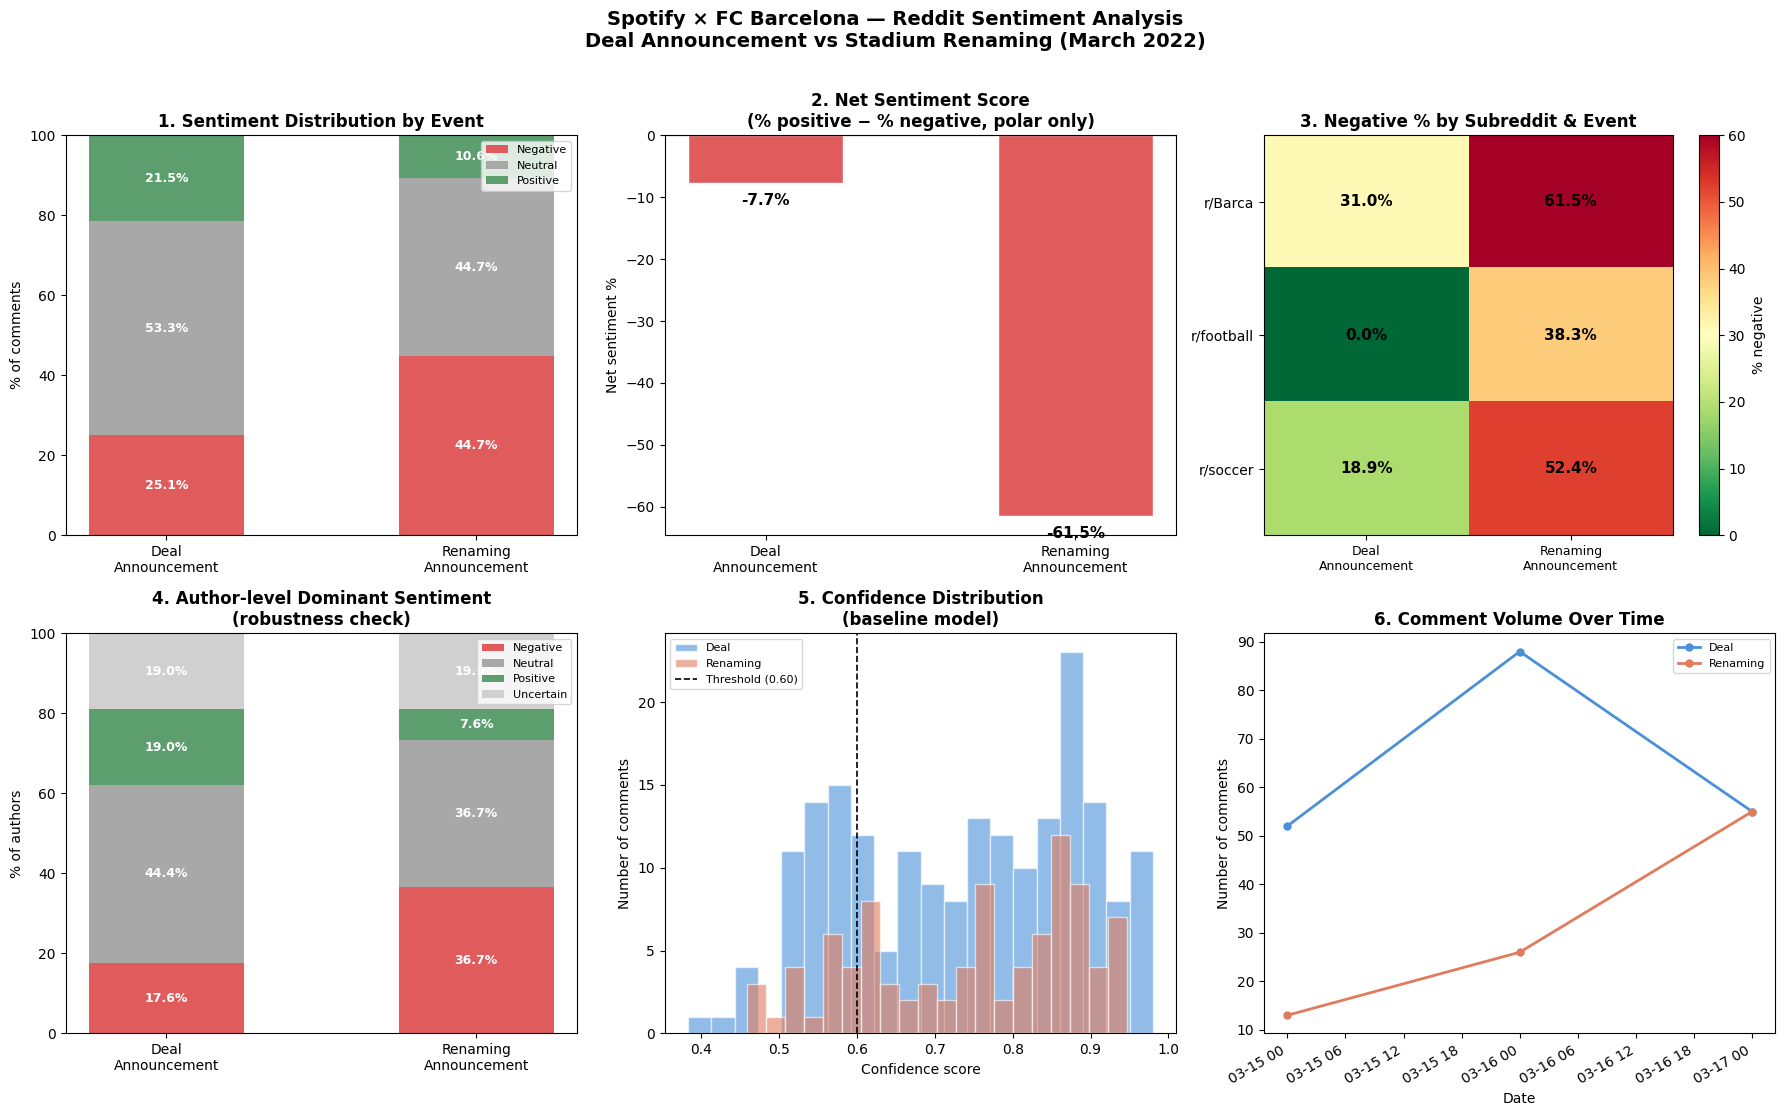

Saved: conclusion_dashboard.png


In [30]:
# ============================================================
# FINAL VISUALISATIONS — Conclusion support
# ============================================================

event_order = ["Deal Announcement", "Renaming Announcement"]
label_cols  = ["negative", "neutral", "positive"]
colors      = {"negative": "#e05c5c", "neutral": "#a8a8a8", "positive": "#5c9e6e"}
uncertain_c = "#d0d0d0"

# --- Resolve column names ---
def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

col_comment_id = find_col(df_filtered, ["comment_id", "Comment ID"])
col_date_day   = find_col(df_filtered, ["date_day", "Date Day", "date"])
col_subreddit  = find_col(df_filtered, ["Subreddit", "subreddit"])
col_topic      = find_col(df_filtered, ["Topic", "topic"])
col_author     = find_col(df_filtered, ["Author", "author"])

df_ev = df_filtered[df_filtered[col_topic].isin(event_order)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle(
    "Spotify × FC Barcelona — Reddit Sentiment Analysis\n"
    "Deal Announcement vs Stadium Renaming (March 2022)",
    fontsize=14, fontweight="bold", y=1.01
)

# ---------------------------------------------------------------
# GRAPH 1 — Stacked bar: sentiment % by event
# ---------------------------------------------------------------
ax = axes[0, 0]
pct = (
    pd.crosstab(df_ev[col_topic], df_ev["roberta_label"], normalize="index")
    .reindex(index=event_order, columns=label_cols, fill_value=0)
    .mul(100)
)
bottoms = np.zeros(len(event_order))
for label in label_cols:
    vals = pct[label].values
    bars = ax.bar(event_order, vals, bottom=bottoms,
                  color=colors[label], label=label.capitalize(), width=0.5)
    for bar, val, bot in zip(bars, vals, bottoms):
        if val > 4:
            ax.text(bar.get_x() + bar.get_width()/2,
                    bot + val/2, f"{val:.1f}%",
                    ha="center", va="center",
                    fontsize=9, color="white", fontweight="bold")
    bottoms += vals
ax.set_title("1. Sentiment Distribution by Event", fontweight="bold")
ax.set_ylabel("% of comments")
ax.set_ylim(0, 100)
ax.legend(loc="upper right", fontsize=8)
ax.set_xticklabels(["Deal\nAnnouncement", "Renaming\nAnnouncement"])

# ---------------------------------------------------------------
# GRAPH 2 — Net sentiment bar (polar only)
# ---------------------------------------------------------------
ax = axes[0, 1]
net_vals = []
for event in event_order:
    ev = df_ev[
        (df_ev[col_topic] == event) &
        (df_ev["roberta_label"].isin(["positive", "negative"]))
    ]
    pos = (ev["roberta_label"] == "positive").mean() * 100
    neg = (ev["roberta_label"] == "negative").mean() * 100
    net_vals.append(round(pos - neg, 1))

bar_colors = [colors["positive"] if v >= 0 else colors["negative"] for v in net_vals]
bars = ax.bar(["Deal\nAnnouncement", "Renaming\nAnnouncement"],
              net_vals, color=bar_colors, width=0.5, edgecolor="white")
for bar, val in zip(bars, net_vals):
    offset = 1.5 if val >= 0 else -3.5
    ax.text(bar.get_x() + bar.get_width()/2,
            val + offset, f"{val:+.1f}%",
            ha="center", fontsize=11, fontweight="bold")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("2. Net Sentiment Score\n(% positive − % negative, polar only)",
             fontweight="bold")
ax.set_ylabel("Net sentiment %")

# ---------------------------------------------------------------
# GRAPH 3 — Subreddit × event heatmap (negative %)
# ---------------------------------------------------------------
ax = axes[0, 2]
heatmap_data = (
    df_ev.groupby([col_subreddit, col_topic])
    .apply(lambda x: round(100 * (x["roberta_label"] == "negative").mean(), 1))
    .unstack(fill_value=0)
    .reindex(columns=event_order)
)
im = ax.imshow(heatmap_data.values, cmap="RdYlGn_r",
               aspect="auto", vmin=0, vmax=60)
ax.set_xticks(range(len(event_order)))
ax.set_xticklabels(["Deal\nAnnouncement", "Renaming\nAnnouncement"], fontsize=9)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)
for i in range(len(heatmap_data.index)):
    for j in range(len(event_order)):
        ax.text(j, i, f"{heatmap_data.values[i, j]:.1f}%",
                ha="center", va="center",
                fontsize=11, fontweight="bold", color="black")
plt.colorbar(im, ax=ax, label="% negative")
ax.set_title("3. Negative % by Subreddit & Event", fontweight="bold")

# ---------------------------------------------------------------
# GRAPH 4 — Author-level dominant sentiment bar
# ---------------------------------------------------------------
ax = axes[1, 0]
if "df_author_event" in dir() and df_author_event is not None:
    auth_pct = (
        pd.crosstab(
            df_author_event["Topic"],
            df_author_event["dominant_sentiment"],
            normalize="index"
        )
        .reindex(
            index=event_order,
            columns=["negative", "neutral", "positive", "uncertain"],
            fill_value=0
        )
        .mul(100)
    )
    auth_label_cols = ["negative", "neutral", "positive", "uncertain"]
    auth_colors     = [colors["negative"], colors["neutral"],
                       colors["positive"], uncertain_c]
    bottoms = np.zeros(len(event_order))
    for label, color in zip(auth_label_cols, auth_colors):
        vals = auth_pct[label].values
        bars = ax.bar(event_order, vals, bottom=bottoms,
                      color=color, label=label.capitalize(), width=0.5)
        for bar, val, bot in zip(bars, vals, bottoms):
            if val > 4:
                ax.text(bar.get_x() + bar.get_width()/2,
                        bot + val/2, f"{val:.1f}%",
                        ha="center", va="center",
                        fontsize=9, color="white", fontweight="bold")
        bottoms += vals
    ax.set_title("4. Author-level Dominant Sentiment\n(robustness check)",
                 fontweight="bold")
    ax.set_ylabel("% of authors")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper right", fontsize=8)
    ax.set_xticklabels(["Deal\nAnnouncement", "Renaming\nAnnouncement"])
else:
    ax.text(0.5, 0.5, "df_author_event not found.\nRun author-level cell first.",
            ha="center", va="center", transform=ax.transAxes, fontsize=10)
    ax.set_title("4. Author-level Dominant Sentiment", fontweight="bold")

# ---------------------------------------------------------------
# GRAPH 5 — Confidence distribution histogram
# ---------------------------------------------------------------
ax = axes[1, 1]
for event, color in zip(event_order, ["#4a90d9", "#e07b5c"]):
    subset = df_ev[df_ev[col_topic] == event]["roberta_confidence"]
    ax.hist(subset, bins=20, alpha=0.6, color=color,
            label=event.replace(" Announcement", ""), edgecolor="white")
ax.axvline(0.60, color="black", linestyle="--",
           linewidth=1.2, label="Threshold (0.60)")
ax.set_title("5. Confidence Distribution\n(baseline model)", fontweight="bold")
ax.set_xlabel("Confidence score")
ax.set_ylabel("Number of comments")
ax.legend(fontsize=8)

# ---------------------------------------------------------------
# GRAPH 6 — Comment volume over time by event
# ---------------------------------------------------------------
ax = axes[1, 2]
if col_date_day is not None and col_comment_id is not None:
    for event, color in zip(event_order, ["#4a90d9", "#e07b5c"]):
        daily = (
            df_ev[df_ev[col_topic] == event]
            .groupby(col_date_day)[col_comment_id]
            .count()
            .reset_index()
            .rename(columns={col_date_day: "date", col_comment_id: "n"})
        )
        ax.plot(daily["date"], daily["n"],
                marker="o",
                label=event.replace(" Announcement", ""),
                color=color, linewidth=2, markersize=5)
    ax.set_title("6. Comment Volume Over Time", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of comments")
    ax.legend(fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
elif col_date_day is not None:
    # fallback — count rows per date without needing comment_id
    for event, color in zip(event_order, ["#4a90d9", "#e07b5c"]):
        daily = (
            df_ev[df_ev[col_topic] == event]
            .groupby(col_date_day)
            .size()
            .reset_index(name="n")
            .rename(columns={col_date_day: "date"})
        )
        ax.plot(daily["date"], daily["n"],
                marker="o",
                label=event.replace(" Announcement", ""),
                color=color, linewidth=2, markersize=5)
    ax.set_title("6. Comment Volume Over Time", fontweight="bold")
    ax.set_xlabel("Date")
    ax.set_ylabel("Number of comments")
    ax.legend(fontsize=8)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right")
else:
    ax.text(0.5, 0.5, "Date column not found in df_filtered.",
            ha="center", va="center", transform=ax.transAxes, fontsize=10)
    ax.set_title("6. Comment Volume Over Time", fontweight="bold")

plt.tight_layout()
plt.savefig("conclusion_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: conclusion_dashboard.png")

## **Key Findings**

- The Renaming Announcement generated significantly more negative sentiment than the Deal Announcement across all model variants and aggregation levels.
- **Baseline (filtered, ≥0.60 confidence):** Deal net +1.4% | Rename net -70.8%
- **Author-level:** 17.6% of authors were negative-dominant for the Deal vs. 36.7% for the Rename — confirming the comment-level trend holds at the user level.
- Adding reply-chain context (context-aware model) made predictions systematically more negative and changed 24.2% of reply labels, suggesting that conversational context carries meaningful sentiment signal in threaded discussions.
- The baseline model was selected for final analysis due to higher interpretability, uniform scoring across comment types, and manual validation of the 8 disagreement cases where context produced overly aggressive negative reclassifications.



---

